<a href="https://colab.research.google.com/github/erikachaichuk/ML/blob/main/risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSIN0274 — Investment Strategies and Risk Management
## Group Coursework
- Section 2: Portfolio Construction (equity screening, ERC weights)
- Section 3: Performance Benchmark
- Section 4: Data and Methodology
- Section 5: Performance Analysis
- Section 6: Risk Analysis (VaR, CVaR, drawdown)
- Section 7: Scenario Analysis

---

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
from scipy.optimize import minimize
import pandas_datareader.data as web
import datetime
import re
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import FancyBboxPatch, Patch

## Section 2: Portfolio Construction
### Equity Screening — S&P 500 Universe

A multi-factor screening methodology is applied to the first 100 S&P 500 constituents, filtering on volatility, beta, ROE, dividend yield, leverage, and liquidity. Stocks are ranked on a composite score and the highest-scoring name(s) selected.

In [ ]:
# ---------------------------------------------------
# S&P 500 universe
# ---------------------------------------------------
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
sp500 = pd.read_html(response.text)[0]
tickers = sp500["Symbol"].str.replace(".", "-", regex=False).tolist()
tickers = tickers[:100]

print(tickers[:10])

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [ ]:
prices = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True,
    group_by="ticker",
    progress=False
)

In [ ]:
# Compute volatility and liquidity
results = []

for ticker in tickers:
    try:
        stock = yf.Ticker(ticker)
        info = stock.info

        px = prices[ticker]["Close"].dropna()
        vol = prices[ticker]["Volume"].dropna()

        if len(px) < 252:
            continue

        returns = px.pct_change().dropna()

        annual_vol = returns.std() * np.sqrt(252)
        avg_daily_volume_usd = (px * vol).mean()

        roe = info.get("returnOnEquity", np.nan)
        dividend_yield = info.get("dividendYield", np.nan)
        debt_to_equity = info.get("debtToEquity", np.nan)
        beta = info.get("beta", np.nan)
        sector = info.get("sector", "Unknown")
        market_cap = info.get("marketCap", np.nan)

        results.append({
            "Ticker": ticker,
            "Sector": sector,
            "Annualised Volatility": annual_vol,
            "ROE": roe,
            "Dividend Yield": dividend_yield,
            "Debt to Equity": debt_to_equity,
            "Beta": beta,
            "Average Daily Volume USD": avg_daily_volume_usd,
            "Market Cap": market_cap
        })

    except Exception as e:
        print(f"Skipped {ticker}: {e}")

sp_df = pd.DataFrame(results)

In [ ]:
sp_df

,Ticker,Sector,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Average Daily Volume USD,Market Cap
0,MMM,Industrials,0.276955,0.71458,2.09,396.497,1.090,4.533337e+08,77901283328
1,AOS,Industrials,0.272464,0.28267,2.50,34.981,1.217,7.300500e+07,7711511552
2,ABT,Healthcare,0.217376,0.12334,2.84,64.773,0.647,6.183225e+08,154707836928
3,ABBV,Healthcare,0.224419,NaN,3.30,NaN,0.305,8.704071e+08,377669615616
4,ACN,Technology,0.259934,0.24763,3.69,25.469,1.071,7.647137e+08,108808937472
...,...,...,...,...,...,...,...,...,...
95,CNC,Healthcare,0.374127,-0.26044,NaN,76.049,1.062,2.838782e+08,29208092672
96,CNP,Utilities,0.203746,0.09561,2.16,215.591,0.476,1.342057e+08,27802202112
97,CF,Basic Materials,0.364307,0.27300,1.60,43.847,0.417,1.899516e+08,19643039744
98,CRL,Healthcare,0.409506,-0.05870,NaN,102.551,1.446,1.387919e+08,7342206464


In [ ]:
sp_df["Debt to Equity"] = sp_df["Debt to Equity"]/100
sp_df["Dividend Yield"] = sp_df["Dividend Yield"]/100


In [ ]:
sp_df

,Ticker,Sector,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Average Daily Volume USD,Market Cap
0,MMM,Industrials,0.276955,0.71458,0.0209,3.96497,1.090,4.533337e+08,77901283328
1,AOS,Industrials,0.272464,0.28267,0.0250,0.34981,1.217,7.300500e+07,7711511552
2,ABT,Healthcare,0.217376,0.12334,0.0284,0.64773,0.647,6.183225e+08,154707836928
3,ABBV,Healthcare,0.224419,NaN,0.0330,NaN,0.305,8.704071e+08,377669615616
4,ACN,Technology,0.259934,0.24763,0.0369,0.25469,1.071,7.647137e+08,108808937472
...,...,...,...,...,...,...,...,...,...
95,CNC,Healthcare,0.374127,-0.26044,NaN,0.76049,1.062,2.838782e+08,29208092672
96,CNP,Utilities,0.203746,0.09561,0.0216,2.15591,0.476,1.342057e+08,27802202112
97,CF,Basic Materials,0.364307,0.27300,0.0160,0.43847,0.417,1.899516e+08,19643039744
98,CRL,Healthcare,0.409506,-0.05870,NaN,1.02551,1.446,1.387919e+08,7342206464


In [ ]:
sp_df = sp_df.dropna(subset=[
    "Annualised Volatility",
    "ROE",
    "Dividend Yield",
    "Debt to Equity",
    "Beta",
    "Average Daily Volume USD"
])


In [ ]:
# Apply screening thresholds
vol_threshold = sp_df["Annualised Volatility"].quantile(0.30)
roe_threshold = sp_df["ROE"].quantile(0.70)

screened = sp_df[
    (sp_df["Annualised Volatility"] <= vol_threshold) &
    (sp_df["ROE"] >= roe_threshold) &
    (sp_df["Dividend Yield"] > 0.02) &
    (sp_df["Debt to Equity"] < 1.5) &
    (sp_df["Average Daily Volume USD"] > 10_000_000) &
    (sp_df["Beta"] < 1.1)
].copy()

In [ ]:
# Composite scoring
screened["Vol Score"] = screened["Annualised Volatility"].rank(ascending=True)
screened["ROE Score"] = screened["ROE"].rank(ascending=False)
screened["Dividend Score"] = screened["Dividend Yield"].rank(ascending=False)
screened["Leverage Score"] = screened["Debt to Equity"].rank(ascending=True)
screened["Liquidity Score"] = screened["Average Daily Volume USD"].rank(ascending=False)
screened["Beta Score"] = screened["Beta"].rank(ascending=True)

screened["Composite Score"] = (
    screened["Vol Score"] +
    screened["ROE Score"] +
    screened["Dividend Score"] +
    screened["Leverage Score"] +
    screened["Liquidity Score"] +
    screened["Beta Score"]
)

screened_sp = screened.sort_values("Composite Score")

In [ ]:
screened_sp

,Ticker,Sector,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Average Daily Volume USD,Market Cap,Vol Score,ROE Score,Dividend Score,Leverage Score,Liquidity Score,Beta Score,Composite Score
51,ADP,Technology,0.210694,0.71208,0.0308,0.69259,0.841,3.974944e+08,88117420032,1.0,1.0,1.0,1.0,1.0,1.0,6.0
74,BR,Technology,0.223101,0.42314,0.0261,1.20878,0.901,9.784054e+07,17282818048,2.0,2.0,2.0,2.0,2.0,2.0,12.0


In [ ]:
len(screened)

2

In [ ]:
# Pick top stocks from different sectors
selected_sp = (
    screened_sp
    .drop_duplicates(subset="Sector")
)

print(selected_sp[[
    "Ticker",
    "Sector",
    "Annualised Volatility",
    "ROE",
    "Dividend Yield",
    "Debt to Equity",
    "Beta",
    "Average Daily Volume USD",
    "Composite Score"
]])

# Save outputs
screened_sp.to_excel("full_stock_screening_results.xlsx", index=False)
selected_sp.to_excel("selected_stocks.xlsx", index=False)

   Ticker      Sector  Annualised Volatility      ROE  Dividend Yield  \
51    ADP  Technology               0.210694  0.71208          0.0308   

    Debt to Equity   Beta  Average Daily Volume USD  Composite Score  
51         0.69259  0.841              3.974944e+08              6.0  


### Equity Screening — MSCI World Universe

The same multi-factor screening process is applied to the top 100 MSCI World constituents (sourced from the locally downloaded iShares MSCI World ETF holdings file) to identify defensive international names with low beta, high ROE, and sufficient liquidity.

In [ ]:
# ---------------------------------------------------
# MSCI
# ---------------------------------------------------
# Read the locally downloaded iShares MSCI World ETF holdings file
with open("iShares-MSCI-World-ETF_fund.xls", "r",
          encoding="utf-8", errors="ignore") as f:
    content = f.read()

# Extract ticker symbols from XML structure
data_pattern = re.compile(r'<ss:Data ss:Type="String">([A-Z]{1,5})</ss:Data>')
all_matches = data_pattern.findall(content)

# Remove currency codes and keep unique equity tickers
currency_codes = {"USD", "EUR", "GBP", "JPY", "CHF", "CAD",
                  "AUD", "SEK", "DKK", "NOK", "HKD", "SGD"}
msci_tickers = list(dict.fromkeys(
    t for t in all_matches
    if t not in currency_codes
    and t.isalpha()
    and len(t) <= 5
))

msci_tickers = msci_tickers[:100]
print(f"Loaded {len(msci_tickers)} MSCI World tickers")
print(msci_tickers[:20])

Loaded 100 MSCI World tickers
['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'MU', 'JPM', 'NYSE', 'LLY', 'AMD', 'XOM', 'BRKB', 'ASML', 'WMT', 'V', 'JNJ']


In [ ]:
# MSCI World constituents from iShares MSCI World ETF holdings file
# Downloaded manually from iShares.com as the API endpoint was blocked
with open("iShares-MSCI-World-ETF_fund.xls", "r",
          encoding="utf-8", errors="ignore") as f:
    content = f.read()

# Extract ticker symbols from XML structure
data_pattern = re.compile(r'<ss:Data ss:Type="String">([A-Z]{1,5})</ss:Data>')
all_matches = data_pattern.findall(content)

# Remove currency codes and keep unique equity tickers
currency_codes = {"USD", "EUR", "GBP", "JPY", "CHF", "CAD",
                  "AUD", "SEK", "DKK", "NOK", "HKD", "SGD"}
msci_tickers = list(dict.fromkeys(
    t for t in all_matches
    if t not in currency_codes
    and t.isalpha()
    and len(t) <= 5
))

msci_tickers = msci_tickers[:100]
print(f"Number of MSCI World tickers: {len(msci_tickers)}")
print(msci_tickers[:20])

Number of MSCI World tickers: 100
['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'MU', 'JPM', 'NYSE', 'LLY', 'AMD', 'XOM', 'BRKB', 'ASML', 'WMT', 'V', 'JNJ']


In [ ]:
msci_prices = yf.download(
    msci_tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True,
    group_by="ticker",
    progress=False
)

print(msci_prices.shape)

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NESN"}}}
ERROR:yfinance:
7 Failed downloads:
ERROR:yfinance:['NOVN', 'NESN', 'HSBA', 'BRKB', 'ABBN']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['NYSE', 'SIE']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-01-01 -> 2026-01-01)')


(1255, 507)


In [ ]:
# Keep only tickers with usable Yahoo price data
valid_msci_tickers = []

for ticker in msci_tickers:
    try:
        px = msci_prices[ticker]["Close"].dropna()
        if len(px) >= 252:
            valid_msci_tickers.append(ticker)
    except:
        pass

print("Valid MSCI tickers:", len(valid_msci_tickers))
print(valid_msci_tickers[:20])

Valid MSCI tickers: 93
['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'MU', 'JPM', 'LLY', 'AMD', 'XOM', 'ASML', 'WMT', 'V', 'JNJ', 'INTC', 'CSCO']


In [ ]:
# Build MSCI dataframe with price + fundamental data
import time

results = []

for ticker in valid_msci_tickers:

    try:
        stock = yf.Ticker(ticker)
        info = stock.info

        px = msci_prices[ticker]["Close"].dropna()
        volume = msci_prices[ticker]["Volume"].dropna()

        returns = px.pct_change().dropna()

        annual_vol = returns.std() * np.sqrt(252)
        avg_daily_volume_usd = (px * volume).mean()

        results.append({
            "Ticker": ticker,
            "Company": info.get("longName"),
            "Sector": info.get("sector"),
            "Country": info.get("country"),
            "Annualised Volatility": annual_vol,
            "ROE": info.get("returnOnEquity"),
            "Dividend Yield": info.get("dividendYield"),
            "Debt to Equity": info.get("debtToEquity"),
            "Beta": info.get("beta"),
            "Average Daily Volume USD": avg_daily_volume_usd,
            "Market Cap": info.get("marketCap")
        })

        time.sleep(0.3)

    except Exception as e:
        print(f"Failed {ticker}: {e}")

msci_df = pd.DataFrame(results)

msci_df.head()

,Ticker,Company,Sector,Country,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Average Daily Volume USD,Market Cap
0,NVDA,NVIDIA Corporation,Technology,United States,0.522247,1.01485,0.02,7.255,2.244,2.097282e+10,5.343290e+12
1,AAPL,Apple Inc.,Technology,United States,0.278626,1.41471,0.36,79.548,1.065,1.193260e+10,4.391079e+12
2,MSFT,Microsoft Corporation,Technology,United States,0.257143,0.34014,0.86,30.271,1.093,8.423567e+09,3.100777e+12
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,United States,0.351060,0.24285,NaN,53.300,1.468,8.986680e+09,2.789749e+12
4,GOOGL,Alphabet Inc.,Communication Services,United States,0.311455,0.38885,0.22,20.026,1.267,4.697230e+09,4.696673e+12


In [ ]:
msci_df = msci_df.dropna(subset=[
    "Annualised Volatility",
    "ROE",
    "Dividend Yield",
    "Debt to Equity",
    "Beta",
    "Average Daily Volume USD",
    "Market Cap"
]).copy()

# yfinance gives debt-to-equity in percent form
msci_df["Debt to Equity"] = msci_df["Debt to Equity"]/100

# if dividend yield is in decimal, this keeps it correct, and if it looks like 2.5 instead of 0.025, convert it
msci_df.loc[msci_df["Dividend Yield"] > 1, "Dividend Yield"] = (
    msci_df.loc[msci_df["Dividend Yield"] > 1, "Dividend Yield"] / 100
)

msci_df["Market Cap (Bn USD)"] = msci_df["Market Cap"] / 1e9

print("Clean MSCI dataframe shape:", msci_df.shape)

msci_df.head()

Clean MSCI dataframe shape: (70, 12)


,Ticker,Company,Sector,Country,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Average Daily Volume USD,Market Cap,Market Cap (Bn USD)
0,NVDA,NVIDIA Corporation,Technology,United States,0.522247,1.01485,0.02,0.07255,2.244,2.097282e+10,5.343290e+12,5343.290065
1,AAPL,Apple Inc.,Technology,United States,0.278626,1.41471,0.36,0.79548,1.065,1.193260e+10,4.391079e+12,4391.078724
2,MSFT,Microsoft Corporation,Technology,United States,0.257143,0.34014,0.86,0.30271,1.093,8.423567e+09,3.100777e+12,3100.777382
4,GOOGL,Alphabet Inc.,Communication Services,United States,0.311455,0.38885,0.22,0.20026,1.267,4.697230e+09,4.696673e+12,4696.673092
5,AVGO,Broadcom Inc.,Technology,United States,0.423096,0.33371,0.62,0.82704,1.440,3.198858e+09,1.946280e+12,1946.280133


In [ ]:
# Apply MSCI factor screening
vol_threshold = msci_df["Annualised Volatility"].quantile(0.40)
roe_threshold = msci_df["ROE"].quantile(0.60)

msci_screened = msci_df[
    (msci_df["Annualised Volatility"] <= vol_threshold) &
    (msci_df["ROE"] >= roe_threshold) &
    (msci_df["Dividend Yield"] > 0.01) &
    (msci_df["Debt to Equity"] < 2.0) &
    (msci_df["Average Daily Volume USD"] > 10_000_000) &
    (msci_df["Beta"] < 1.2)
].copy()

print("MSCI stocks after screening:", len(msci_screened))

msci_screened

MSCI stocks after screening: 5


,Ticker,Company,Sector,Country,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Average Daily Volume USD,Market Cap,Market Cap (Bn USD)
16,V,Visa Inc.,Financial Services,United States,0.226780,0.60349,0.8100,0.67233,0.784,1.758796e+09,6.274043e+11,627.404308
32,KO,The Coca-Cola Company,Consumer Defensive,United States,0.158350,0.43372,0.0259,1.24943,0.356,8.690818e+08,3.524594e+11,352.459358
74,TJX,"The TJX Companies, Inc.",Consumer Cyclical,United States,0.227706,0.59129,0.0127,1.32375,0.637,4.896982e+08,1.666241e+11,166.624084
77,GILD,"Gilead Sciences, Inc.",Healthcare,United States,0.236233,0.43360,0.0251,0.94635,0.332,5.379451e+08,1.620249e+11,162.024882
78,UNP,Union Pacific Corporation,Industrials,United States,0.225167,0.40686,0.0203,1.62246,0.994,6.151378e+08,1.612288e+11,161.228767


In [ ]:
# Composite scoring
msci_screened["Vol Score"] = msci_screened["Annualised Volatility"].rank(ascending=True)
msci_screened["ROE Score"] = msci_screened["ROE"].rank(ascending=False)
msci_screened["Dividend Score"] = msci_screened["Dividend Yield"].rank(ascending=False)
msci_screened["Leverage Score"] = msci_screened["Debt to Equity"].rank(ascending=True)
msci_screened["Liquidity Score"] = msci_screened["Average Daily Volume USD"].rank(ascending=False)
msci_screened["Beta Score"] = msci_screened["Beta"].rank(ascending=True)

msci_screened["Composite Score"] = (
    msci_screened["Vol Score"] +
    msci_screened["ROE Score"] +
    msci_screened["Dividend Score"] +
    msci_screened["Leverage Score"] +
    msci_screened["Liquidity Score"] +
    msci_screened["Beta Score"]
)

msci_screened = msci_screened.sort_values("Composite Score")

msci_screened[[
    "Ticker",
    "Company",
    "Sector",
    "Country",
    "Annualised Volatility",
    "ROE",
    "Dividend Yield",
    "Debt to Equity",
    "Beta",
    "Market Cap (Bn USD)",
    "Composite Score"
]]

,Ticker,Company,Sector,Country,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Market Cap (Bn USD),Composite Score
16,V,Visa Inc.,Financial Services,United States,0.226780,0.60349,0.8100,0.67233,0.784,627.404308,11.0
32,KO,The Coca-Cola Company,Consumer Defensive,United States,0.158350,0.43372,0.0259,1.24943,0.356,352.459358,13.0
77,GILD,"Gilead Sciences, Inc.",Healthcare,United States,0.236233,0.43360,0.0251,0.94635,0.332,162.024882,19.0
74,TJX,"The TJX Companies, Inc.",Consumer Cyclical,United States,0.227706,0.59129,0.0127,1.32375,0.637,166.624084,23.0
78,UNP,Union Pacific Corporation,Industrials,United States,0.225167,0.40686,0.0203,1.62246,0.994,161.228767,24.0


In [ ]:
# Select top 3 international stocks
selected_msci = (
    msci_screened
    .drop_duplicates(subset="Sector")
    .head(3)
)

selected_msci[[
    "Ticker",
    "Company",
    "Sector",
    "Country",
    "Annualised Volatility",
    "ROE",
    "Dividend Yield",
    "Debt to Equity",
    "Beta",
    "Market Cap (Bn USD)",
    "Composite Score"
]]

,Ticker,Company,Sector,Country,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Market Cap (Bn USD),Composite Score
16,V,Visa Inc.,Financial Services,United States,0.226780,0.60349,0.8100,0.67233,0.784,627.404308,11.0
32,KO,The Coca-Cola Company,Consumer Defensive,United States,0.158350,0.43372,0.0259,1.24943,0.356,352.459358,13.0
77,GILD,"Gilead Sciences, Inc.",Healthcare,United States,0.236233,0.43360,0.0251,0.94635,0.332,162.024882,19.0


In [ ]:
# ---------------------------------------------------
# Final Selection
# ---------------------------------------------------
final_equity_selection = pd.concat(
    [selected_sp, selected_msci],
    ignore_index=True
)

final_equity_selection = (
    final_equity_selection
    .drop_duplicates(subset="Ticker")
)

final_equity_selection = (
    final_equity_selection
    .sort_values("Composite Score")
)

final_equity_selection[[
    "Ticker",
    "Company",
    "Sector",
    "Country",
    "Annualised Volatility",
    "ROE",
    "Dividend Yield",
    "Debt to Equity",
    "Beta",
    "Market Cap (Bn USD)",
    "Composite Score"
]]

,Ticker,Company,Sector,Country,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Market Cap (Bn USD),Composite Score
0,ADP,NaN,Technology,NaN,0.210694,0.71208,0.0308,0.69259,0.841,NaN,6.0
1,V,Visa Inc.,Financial Services,United States,0.226780,0.60349,0.8100,0.67233,0.784,627.404308,11.0
2,KO,The Coca-Cola Company,Consumer Defensive,United States,0.158350,0.43372,0.0259,1.24943,0.356,352.459358,13.0
3,GILD,"Gilead Sciences, Inc.",Healthcare,United States,0.236233,0.43360,0.0251,0.94635,0.332,162.024882,19.0


In [ ]:
final_equity_selection["Weight"] = (1/len(final_equity_selection))

final_equity_selection

,Ticker,Sector,Annualised Volatility,ROE,Dividend Yield,Debt to Equity,Beta,Average Daily Volume USD,Market Cap,Vol Score,ROE Score,Dividend Score,Leverage Score,Liquidity Score,Beta Score,Composite Score,Company,Country,Market Cap (Bn USD),Weight
0,ADP,Technology,0.210694,0.71208,0.0308,0.69259,0.841,3.974944e+08,8.811742e+10,1.0,1.0,1.0,1.0,1.0,1.0,6.0,NaN,NaN,NaN,0.25
1,V,Financial Services,0.226780,0.60349,0.8100,0.67233,0.784,1.758796e+09,6.274043e+11,3.0,1.0,1.0,1.0,1.0,4.0,11.0,Visa Inc.,United States,627.404308,0.25
2,KO,Consumer Defensive,0.158350,0.43372,0.0259,1.24943,0.356,8.690818e+08,3.524594e+11,1.0,3.0,2.0,3.0,2.0,2.0,13.0,The Coca-Cola Company,United States,352.459358,0.25
3,GILD,Healthcare,0.236233,0.43360,0.0251,0.94635,0.332,5.379451e+08,1.620249e+11,5.0,4.0,3.0,2.0,4.0,1.0,19.0,"Gilead Sciences, Inc.",United States,162.024882,0.25


---
## Section 4: Data and Methodology
### Instrument Universe, Data Download and Cleaning

All 13 portfolio instruments are downloaded from Yahoo Finance on a total-return basis (`auto_adjust=True`), covering 26 April 2021 to 13 May 2026. Instruments trade across LSE, Xetra, Euronext, and NYSE, so a common-trading-day intersection is applied: any date on which any instrument lacks a price is dropped. Log returns are computed as $r_t = \ln(P_t / P_{t-1})$ and annualised on a 252-day convention.

The ECB deposit facility rate (from FRED) is used as the risk-free rate throughout.

In [ ]:
# RF as ECB deposit facility rate from FRED
rf = web.DataReader('ECBDFR', 'fred',
                    start='2021-04-26',
                    end='2026-05-13')

# Average over the sample period
rf_mean = rf['ECBDFR'].mean()
print(f"Average ECB deposit rate: {rf_mean:.4f}%")
print(f"As daily rate: {rf_mean/252/100:.8f}")

Average ECB deposit rate: 1.9347%
As daily rate: 0.00007677


In [ ]:
START_DATE = "2021-04-26"
END_DATE   = "2026-05-13"
TRADING_DAYS = 252
RISK_FREE_ANNUAL = rf_mean/100

# Bloomberg ticker to Yahoo Finance symbol mapping
PORTFOLIO = {
    "4GLD (Xetra Gold)":        ("4GLD GY Equity",  "4GLD.DE"),
    "WCOB (WT Enh Commodity)":  ("WCOB LN Equity",  "WCOB.L"),
    "INFR (Glob Infra)":        ("INFR LN Equity",  "INFR.L"),
    "ARCC (Ares Capital)":      ("ARCC US Equity",  "ARCC"),
    "IS15 (Glob Corp Bond)":    ("IS15 LN Equity",  "IS15.L"),
    "IGILL (Glob InflLink)":    ("IGILL EB Equity", "IGIL.L"),
    "XGIG (Glob InflLink)":     ("XGIG LN Equity",  "XGIG.L"),
    "IHYU (Glob High Yield)":   ("IHYU LN Equity",  "IHYU.L"),
    "IEMB (EM Bond)":           ("IEMB LN Equity",  "IEMB.L"),
    "ADP (Auto Data Proc)":     ("ADP US Equity",   "ADP"),
    "V (Visa)":                 ("V US Equity",     "V"),
    "KO (Coca-Cola)":           ("KO US Equity",    "KO"),
    "3i Group (PE proxy)":      ("III LN Equity",   "III.L"),
}

INSTRUMENTS = dict(PORTFOLIO)

# Solvency II standard-formula SCR charges (decimal)
SCR_CHARGE = {
    "4GLD (Xetra Gold)":       0.35,   # commodity risk sub-module
    "WCOB (WT Enh Commodity)": 0.35,   # commodity risk sub-module
    "INFR (Glob Infra)":       0.22,   # LTEI-eligible infrastructure equity
    "ARCC (Ares Capital)":     0.49,   # Type 2 equity (non-EEA BDC)
    "IS15 (Glob Corp Bond)":   0.10,   # spread risk (approx, duration-dependent)
    "IGILL (Glob InflLink)":   0.05,   # govt-linked, low spread SCR
    "XGIG (Glob InflLink)":    0.05,   # govt-linked, low spread SCR
    "IHYU (Glob High Yield)":  0.25,   # spread risk (high yield, approx)
    "IEMB (EM Bond)":          0.18,   # spread risk (EM sovereign, approx)
    "ADP (Auto Data Proc)":    0.39,   # Type 1 equity
    "V (Visa)":                0.39,   # Type 1 equity
    "KO (Coca-Cola)":          0.39,   # Type 1 equity
    "3i Group (PE proxy)":     0.49,   # Type 2 equity (listed PE, non-EEA treatment)
}

In [ ]:
# Price data (total return: auto_adjust=True)
def download_prices(instruments, start, end):
    """Download dividend/coupon-adjusted close (total return). Returns the
    adjusted-close DataFrame and a list of labels that failed."""
    yahoo_map = {label: y for label, (bbg, y) in instruments.items()}
    symbols = list(yahoo_map.values())

    raw = yf.download(
        symbols,
        start=start,
        end=end,
        auto_adjust=True,      # <-- total return: dividends/coupons reinvested
        progress=False,
    )

    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].copy()
        prices.columns = [symbols[0]]

    # Map Yahoo symbols back to friendly labels
    inv = {y: label for label, y in yahoo_map.items()}
    prices = prices.rename(columns=inv)

    failed = [label for label in instruments
              if label not in prices.columns or prices[label].dropna().empty]
    prices = prices.drop(
        columns=[c for c in prices.columns if prices[c].dropna().empty],
        errors="ignore",
    )
    return prices, failed

In [ ]:
# Metrics (identical methodology to the returns.csv analysis)
def compute_metrics(prices):
    simple = prices.pct_change().dropna(how="all")
    log_ret = np.log(1.0 + simple)              # ln(1 + r)
    rf_daily = RISK_FREE_ANNUAL / TRADING_DAYS

    rows = []
    for col in prices.columns:
        r_log = log_ret[col].dropna()
        r_simple = simple[col].dropna()
        n = len(r_log)
        if n == 0:
            continue

        mean_log_ann = r_log.mean() * TRADING_DAYS
        geo_return   = np.exp(mean_log_ann) - 1.0
        vol_ann      = r_log.std() * np.sqrt(TRADING_DAYS)
        sharpe       = ((r_log.mean() - rf_daily) * TRADING_DAYS) / vol_ann
        cum_return   = (1.0 + r_simple).prod() - 1.0

        scr = SCR_CHARGE.get(col, np.nan)
        ros = geo_return / scr if scr and not np.isnan(scr) else np.nan

        rows.append({
            "Instrument": col,
            "Geo Return (ann)": round(geo_return, 4),
            "Volatility (ann)": round(vol_ann, 4),
            "Sharpe": round(sharpe, 3),
            "Cumulative": round(cum_return, 4),
            "SCR": scr,
            "Return-on-SCR": round(ros, 4) if not np.isnan(ros) else np.nan,
        })

    return pd.DataFrame(rows).set_index("Instrument")

In [ ]:
if __name__ == "__main__":
    print(f"Downloading {len(INSTRUMENTS)} instruments "
          f"({START_DATE} to {END_DATE}) — total-return basis\n")

    prices, failed = download_prices(INSTRUMENTS, START_DATE, END_DATE)

    if failed:
        print("WARNING — these tickers returned no data. Verify the Yahoo "
              "symbol on finance.yahoo.com and update the mapping:")
        for f in failed:
            bbg, y = INSTRUMENTS[f]
            print(f"   - {f:26s}  Bloomberg='{bbg}'  tried Yahoo='{y}'")
        print()

    # --- Align to common trading days ---------------------------------
    # Instruments trade on different exchanges (.L, .DE, .AS, US)
    rows_before = len(prices)
    prices = prices.dropna(how="any")
    rows_after = len(prices)
    print(f"Common-trading-day alignment: dropped "
          f"{rows_before - rows_after} of {rows_before} dates with one or "
          f"more missing prices; {rows_after} fully-populated days retained.\n")

    print("Data coverage (first / last valid date, obs):")
    full_n = None
    for col in prices.columns:
        s = prices[col].dropna()
        n = len(s)
        full_n = max(full_n or 0, n)
        print(f"   {col:28s}  {s.index.min().date()} -> "
              f"{s.index.max().date()}  ({n} obs)")
    # Flag short histories (e.g. funds launched after START_DATE)
    print("\nShort-history flags (fewer obs than the longest series):")
    any_short = False
    for col in prices.columns:
        n = len(prices[col].dropna())
        if full_n and n < full_n - 5:        # tolerance for odd holidays
            any_short = True
            print(f"   ! {col:28s} only {n} obs (vs {full_n}). "
                  f"Not directly comparable over the full window.")
    if not any_short:
        print("   none — all series cover effectively the same window.")

    metrics = compute_metrics(prices)
    pd.set_option("display.width", 160)
    pd.set_option("display.max_columns", 20)
    pd.set_option("display.max_rows", 40)
    print("\nPerformance summary "
          "(total return, log-return methodology, 252-day annualisation):\n")
    print(metrics.to_string())

    simple = prices.pct_change()
    log_ret = np.log(1.0 + simple).dropna(how="all")
    print("\nCorrelation matrix (log returns):\n")
    print(log_ret.corr().round(2).to_string())

metrics.to_latex("summary_statistics.tex", float_format="%.4f", caption="Descriptive statistics per instrument (total return, log-return methodology, 252-day annualisation).", label="app:stats")


Common-trading-day alignment: dropped 79 of 1305 dates with one or more missing prices; 1226 fully-populated days retained.

Data coverage (first / last valid date, obs):
   4GLD (Xetra Gold)             2021-04-26 -> 2026-05-12  (1226 obs)
   ADP (Auto Data Proc)          2021-04-26 -> 2026-05-12  (1226 obs)
   ARCC (Ares Capital)           2021-04-26 -> 2026-05-12  (1226 obs)
   IEMB (EM Bond)                2021-04-26 -> 2026-05-12  (1226 obs)
   IGILL (Glob InflLink)         2021-04-26 -> 2026-05-12  (1226 obs)
   IHYU (Glob High Yield)        2021-04-26 -> 2026-05-12  (1226 obs)
   3i Group (PE proxy)           2021-04-26 -> 2026-05-12  (1226 obs)
   INFR (Glob Infra)             2021-04-26 -> 2026-05-12  (1226 obs)
   IS15 (Glob Corp Bond)         2021-04-26 -> 2026-05-12  (1226 obs)
   KO (Coca-Cola)                2021-04-26 -> 2026-05-12  (1226 obs)
   V (Visa)                      2021-04-26 -> 2026-05-12  (1226 obs)
   WCOB (WT Enh Commodity)       2021-04-26 -> 2026-05-12 

In [ ]:
# Export daily data for the originally defined period
prices.index.name = "Date"
prices.to_csv("portfolio_daily_prices.csv")

# CSV: daily simple returns (drop the first all-NaN row)
daily_returns = simple.dropna(how="all")
daily_returns.index.name = "Date"
daily_returns.to_csv("portfolio_daily_returns.csv")

# Excel: one workbook, separate sheets for prices/returns/summary
xlsx_path = "portfolio_daily_data.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as xl:
  prices.round(6).to_excel(xl, sheet_name="Daily Prices (Total Ret)")
  daily_returns.round(8).to_excel(xl, sheet_name="Daily Returns")
  log_ret.round(8).to_excel(xl, sheet_name="Daily Log Returns")
  metrics.to_excel(xl, sheet_name="Performance Summary")
  log_ret.corr().round(4).to_excel(xl, sheet_name="Correlation Matrix")

print(f"\nSaved:"
f"\n  portfolio_daily_prices.csv      ({prices.shape[0]} rows x "
f"{prices.shape[1]} instruments)"
f"\n  portfolio_daily_returns.csv     ({daily_returns.shape[0]} rows)"
f"\n  {xlsx_path}  (5 sheets: prices, returns, log returns, "
f"summary, correlation)")


Saved:
  portfolio_daily_prices.csv      (1226 rows x 13 instruments)
  portfolio_daily_returns.csv     (1225 rows)
  portfolio_daily_data.xlsx  (5 sheets: prices, returns, log returns, summary, correlation)


---
## Intra-Sleeve Weighting — Equal Risk Contribution

Within each sleeve, weights are determined by the **Equal Risk Contribution (ERC)** principle: every instrument contributes an identical share of that sleeve's total risk. This prevents the most volatile holding from dominating, directly supporting the capital-preservation mandate of a Solvency II insurer.

$$w^* = \arg\min_w \sum_i \left(RC_i - \frac{\sigma_p}{n}\right)^2 \quad \text{s.t.} \quad \sum_i w_i = 1,\ w_i \ge 0$$

The within-sleeve ERC weights are then rescaled to the strategic sleeve targets (Fixed Income 35%, Equity 25%, Alternatives 22.5%, Commodities 17.5%). The ERC methodology is introduced in Section 2 of the report; it is computed here as it depends on the covariance matrix estimated from the downloaded return series.

In [ ]:
INPUT_CSV = "portfolio_daily_returns.csv"
RF_ANNUAL = rf_mean/100
TRADING_DAYS = 252

# Level 1 — sleeve targets (must sum to 1.0)
SLEEVES = {
    "Fixed Income": (["IS15 (Glob Corp Bond)", "IGILL (Glob InflLink)",
                      "XGIG (Glob InflLink)", "IHYU (Glob High Yield)",
                      "IEMB (EM Bond)"], 0.350),
    "Equity":       (["ADP (Auto Data Proc)", "V (Visa)",
                      "KO (Coca-Cola)"], 0.250),
    "Alternatives": (["INFR (Glob Infra)", "ARCC (Ares Capital)",
                      "3i Group (PE proxy)"], 0.225),
    "Commodities":  (["4GLD (Xetra Gold)",
                      "WCOB (WT Enh Commodity)"], 0.175),
}

WITHIN_SLEEVE_BOUNDS = (0, 1)

# Data
def load_log_returns(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    # Defensive: drop any fully-empty rows, then convert to log returns
    df = df.dropna(how="all")
    return np.log(1.0 + df)

In [ ]:
# Method: True equal risk contribution (corr-aware)
def erc_weights(cov, bounds):
    """Weights (sum to 1) where each asset's risk contribution is equal."""
    n = cov.shape[0]

    def dispersion(w):
        port_var = w @ cov @ w
        if port_var <= 0:
            return 1e6
        mrc = cov @ w                          # marginal risk contribution
        rc = w * mrc / np.sqrt(port_var)       # risk contribution per asset
        target = np.sqrt(port_var) / n         # equal target
        return np.sum((rc - target) ** 2)

    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    bnds = [bounds] * n
    w0 = np.ones(n) / n
    res = minimize(dispersion, w0, method="SLSQP",
                   bounds=bnds, constraints=cons,
                   options={"ftol": 1e-14, "maxiter": 2000})
    return res.x

In [ ]:
# APPLY A METHOD WITHIN EACH SLEEVE, RESCALE TO SLEEVE TARGET
def build_portfolio(log_ret, method_fn, label):
    rows = {}                                  # <-- was: weights = {}
    print("\n" + "=" * 64)
    print(f"{label}")
    print("=" * 64)

    for sleeve, (members, target) in SLEEVES.items():
        cov = log_ret[members].cov().values * TRADING_DAYS
        w_in = method_fn(cov, WITHIN_SLEEVE_BOUNDS)
        w_in = np.clip(w_in, 0, None)
        w_in = w_in / w_in.sum()
        w_scaled = w_in * target

        pv = w_in @ cov @ w_in
        rc = w_in * (cov @ w_in) / np.sqrt(pv)
        rc_pct = rc / rc.sum()

        print(f"\n{sleeve}  (target {target*100:.1f}%)")
        print(f"  {'Instrument':28s}{'Weight':>9s}{'RiskShr':>10s}")
        for m, ws, rc_i in zip(members, w_scaled, rc_pct):
            rows[m] = {"Sleeve": sleeve,
                       "Weight": ws,
                       "Risk Share": rc_i}     # <-- store both
            print(f"  {m:28s}{ws*100:7.2f}%{rc_i*100:9.1f}%")

    return pd.DataFrame.from_dict(rows, orient="index")

In [ ]:
if __name__ == "__main__":
    assert abs(sum(t for _, t in SLEEVES.values()) - 1.0) < 1e-9, \
        "Sleeve targets must sum to 1.0"

    log_ret = load_log_returns(INPUT_CSV)
    rp = build_portfolio(log_ret, erc_weights,
                         "RISK PARITY (Equal Risk Contribution)")

    rp.index.name = "Instrument"
    rp = rp.round(4)

    rp.to_latex("risk_parity_weights.tex", float_format="%.4f",
                caption="Intra-sleeve weights and realised risk "
                        "contributions (Equal Risk Contribution).",
                label="tab:weights")
    print("\nSaved: risk_parity_weights.tex")


RISK PARITY (Equal Risk Contribution)

Fixed Income  (target 35.0%)
  Instrument                     Weight   RiskShr
  IS15 (Glob Corp Bond)         13.62%     20.0%
  IGILL (Glob InflLink)          4.27%     20.0%
  XGIG (Glob InflLink)           5.51%     20.0%
  IHYU (Glob High Yield)         6.78%     20.0%
  IEMB (EM Bond)                 4.82%     20.0%

Equity  (target 25.0%)
  Instrument                     Weight   RiskShr
  ADP (Auto Data Proc)           7.29%     33.3%
  V (Visa)                       7.05%     33.3%
  KO (Coca-Cola)                10.66%     33.3%

Alternatives  (target 22.5%)
  Instrument                     Weight   RiskShr
  INFR (Glob Infra)             11.33%     33.3%
  ARCC (Ares Capital)            6.82%     33.3%
  3i Group (PE proxy)            4.34%     33.3%

Commodities  (target 17.5%)
  Instrument                     Weight   RiskShr
  4GLD (Xetra Gold)              8.57%     50.0%
  WCOB (WT Enh Commodity)        8.93%     50.0%

Saved: ris

In [ ]:
df = pd.read_csv("portfolio_daily_returns.csv", index_col=0, parse_dates=True)
df.index.name = "Date"
print(f"Data loaded: {df.shape[0]} trading days, {df.shape[1]} instruments")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}\n")

Data loaded: 1225 trading days, 13 instruments
Date range: 2021-04-27 to 2026-05-12



In [ ]:
df

,4GLD (Xetra Gold),ADP (Auto Data Proc),ARCC (Ares Capital),IEMB (EM Bond),IGILL (Glob InflLink),IHYU (Glob High Yield),3i Group (PE proxy),INFR (Glob Infra),IS15 (Glob Corp Bond),KO (Coca-Cola),V (Visa),WCOB (WT Enh Commodity),XGIG (Glob InflLink)
Date,,,,,,,,,,,,,
2021-04-27,0.000465,0.003843,0.005644,-0.004168,-0.000877,-0.001813,-0.003187,-0.005859,-0.000656,-0.001491,-0.001867,-0.001276,-0.001455
2021-04-28,-0.004138,-0.047323,-0.011735,-0.001273,0.000988,-0.000669,0.001199,0.002401,0.001220,0.000187,0.015397,0.002556,-0.005233
2021-04-29,-0.004706,0.009538,0.012390,0.001092,-0.001261,0.002488,0.014371,-0.003702,-0.002061,0.012502,0.014607,-0.008214,-0.000366
2021-04-30,0.006092,-0.007484,-0.018358,0.003367,-0.003678,-0.001050,0.009051,0.012787,0.001408,-0.005161,-0.013932,0.006140,0.000550
2021-05-04,0.010543,0.037328,-0.012987,-0.001179,0.005676,-0.001720,-0.043682,-0.002914,0.000281,0.002964,-0.006551,0.016321,0.008237
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-06,0.021162,-0.016144,-0.009819,0.007137,0.004344,0.002513,0.021827,-0.011177,0.002482,0.009557,-0.010030,-0.020622,-0.003195
2026-05-07,0.010128,0.033253,-0.010438,-0.000322,-0.002834,-0.002194,-0.018737,-0.012502,0.000099,-0.010097,0.007779,-0.012206,0.003205
2026-05-08,-0.007327,-0.005091,0.002637,0.000000,0.005026,0.000209,-0.010884,-0.000867,0.000990,-0.000128,-0.007750,0.012666,0.004792


In [ ]:
# Weights
WEIGHTS = {
    "4GLD (Xetra Gold)": 0.0857,
    "WCOB (WT Enh Commodity)": 0.0893,
    "3i Group (PE proxy)": 0.0434,
    "INFR (Glob Infra)": 0.1133,
    "ARCC (Ares Capital)": 0.0682,
    "IS15 (Glob Corp Bond)": 0.1362,
    "IGILL (Glob InflLink)": 0.0427,
    "XGIG (Glob InflLink)": 0.0551,
    "IHYU (Glob High Yield)": 0.0678,
    "IEMB (EM Bond)": 0.0482,
    "ADP (Auto Data Proc)": 0.0729,
    "V (Visa)": 0.0705,
    "KO (Coca-Cola)": 0.1067,
}

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, "Weights must sum to 100%"
print("Weights verified: sum =", round(sum(WEIGHTS.values()), 4))

# Align weights with dataframe columns
weights_series = pd.Series(WEIGHTS)

Weights verified: sum = 1.0


In [ ]:
# Portfolio returns
# Weighted sum of individual instrument returns
portfolio_returns = (df * weights_series).sum(axis=1)
portfolio_returns.name = "Portfolio"

print(f"\nPortfolio return series: {len(portfolio_returns)} observations")
print(f"Mean daily return:       {portfolio_returns.mean():.6f}")
print(f"Std daily return:        {portfolio_returns.std():.6f}\n")



Portfolio return series: 1225 observations
Mean daily return:       0.000335
Std daily return:        0.004295



In [ ]:
portfolio_return_ann = (np.exp(portfolio_returns.mean() * 252) - 1) * 100
portfolio_vol_ann = portfolio_returns.std() * np.sqrt(252) * 100

print("Annualised return:", portfolio_return_ann)
print("Annualised volatility:", portfolio_vol_ann)

Annualised return: 8.8060939157665
Annualised volatility: 6.81819257826696


In [ ]:
print(df.columns.tolist())
print(weights_series.index.tolist())

# Check all weight keys exist in dataframe
missing = [col for col in weights_series.index if col not in df.columns]
print("Missing columns:", missing)

['4GLD (Xetra Gold)', 'ADP (Auto Data Proc)', 'ARCC (Ares Capital)', 'IEMB (EM Bond)', 'IGILL (Glob InflLink)', 'IHYU (Glob High Yield)', '3i Group (PE proxy)', 'INFR (Glob Infra)', 'IS15 (Glob Corp Bond)', 'KO (Coca-Cola)', 'V (Visa)', 'WCOB (WT Enh Commodity)', 'XGIG (Glob InflLink)']
['4GLD (Xetra Gold)', 'WCOB (WT Enh Commodity)', '3i Group (PE proxy)', 'INFR (Glob Infra)', 'ARCC (Ares Capital)', 'IS15 (Glob Corp Bond)', 'IGILL (Glob InflLink)', 'XGIG (Glob InflLink)', 'IHYU (Glob High Yield)', 'IEMB (EM Bond)', 'ADP (Auto Data Proc)', 'V (Visa)', 'KO (Coca-Cola)']
Missing columns: []


---
## Section 5: Performance Analysis

**Custom blended benchmark**: Each sleeve is represented by a single broad, investable index ETF:

| Sleeve | Weight | Index | ETF (Yahoo) |
|---|---|---|---|
| Fixed Income | 35% | Bloomberg Global Aggregate Bond | AGGG.L |
| Equity | 25% | MSCI World | IWRD.L |
| Alternatives | 22.5% | FTSE Global Core Infrastructure | INFR.L |
| Commodities | 17.5% | Bloomberg Commodity Index | CMOD.L |

The benchmark return series is constructed as a daily fixed-weight combination of these four index log returns — consistent with the constant-weight methodology applied to the portfolio.

### Sharpe Ratio
$$S = \frac{\bar{R}_p - R_f}{\hat{\sigma}_p}$$
Measures risk-adjusted excess return over the risk free rate (ECB deposit rate).

### Sortino Ratio
$$\text{Sortino} = \frac{\bar{R}_p - R_f}{\sigma_d}$$
where $\sigma_d$ is downside deviation. One-sided loss measure — upside volatility does not consume regulatory capital.

### Information Ratio
$$IR = \frac{\bar{R}_p - \bar{R}_b}{\sigma_{\text{TE}}}$$
Measures active return per unit of tracking error — quantifies the consistency of outperformance.

In [ ]:
# Download benchmark data

BENCHMARK_TICKERS = {
    'Agg Bond'    : 'AGGG.L',   # Bloomberg Global Aggregate Bond  — Fixed Income 35%
    'MSCI World'  : 'IWRD.L',   # MSCI World                       — Equity 25%
    'Global Infra': 'INFR.L',   # FTSE Global Core Infrastructure  — Alternatives 22.5%
    'Commodity'   : 'CMOD.L',   # Bloomberg Commodity Index        — Commodities 17.5%
}

BENCHMARK_SLEEVE_WEIGHTS = [0.35, 0.25, 0.225, 0.175]  # must match dict order above

#Pull from yahoo finance
bench_raw = yf.download(
    list(BENCHMARK_TICKERS.values()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

bench_prices = bench_raw['Close'].copy()
bench_prices.columns = list(BENCHMARK_TICKERS.keys())

# Align to the same common trading days  used for the portfolio (df index)
common_idx        = df.index.intersection(bench_prices.dropna(how='any').index)
bench_prices_aln  = bench_prices.loc[common_idx]
port_ret_aligned  = portfolio_returns.loc[common_idx]

# Daily log returns for each benchmark component
bench_log = np.log(bench_prices_aln / bench_prices_aln.shift(1)).dropna()
port_ret_aligned = port_ret_aligned.loc[bench_log.index]

# Blended benchmark return = weighted sum of component log returns
benchmark_returns = bench_log @ BENCHMARK_SLEEVE_WEIGHTS
benchmark_returns.name = 'Benchmark'

print(f'Benchmark series : {len(benchmark_returns)} observations')
print(f'  Period         : {benchmark_returns.index[0].date()} to {benchmark_returns.index[-1].date()}')
print(f'  Components     : {list(BENCHMARK_TICKERS.keys())}')
print(f'  Sleeve weights : {BENCHMARK_SLEEVE_WEIGHTS}')


Benchmark series : 1224 observations
  Period         : 2021-04-28 to 2026-05-12
  Components     : ['Agg Bond', 'MSCI World', 'Global Infra', 'Commodity']
  Sleeve weights : [0.35, 0.25, 0.225, 0.175]


In [ ]:
#Compute performance metrics for portfolio and benchmark

RF_DAILY_S5 = RF_ANNUAL / TRADING_DAYS

def perf_metrics(ret, label):
    """Annualised performance statistics from a daily log-return series."""
    r = ret.dropna()

    geo_ret = np.exp(r.mean() * TRADING_DAYS) - 1      # geometric annualised return
    ann_vol = r.std() * np.sqrt(TRADING_DAYS)     # annualised volatility
    sharpe  = (r.mean() - RF_DAILY_S5) * TRADING_DAYS / ann_vol

    # Sortino
    downside = r[r < RF_DAILY_S5]
    dd_vol   = np.sqrt((downside - RF_DAILY_S5).pow(2).mean()) * np.sqrt(TRADING_DAYS)
    sortino  = (r.mean() - RF_DAILY_S5) * TRADING_DAYS / dd_vol

    # Maximum drawdown
    cum    = np.exp(r.cumsum())
    peak   = cum.cummax()
    max_dd = ((cum - peak) / peak).min()

    return {
        'Label'               : label,
        'Ann. Return (%)'     : round(geo_ret * 100, 2),
        'Ann. Volatility (%)' : round(ann_vol * 100, 2),
        'Sharpe Ratio'        : round(sharpe,        3),
        'Sortino Ratio'       : round(sortino,        3),
        'Max Drawdown (%)'    : round(max_dd * 100,   2),
    }

pm = perf_metrics(port_ret_aligned,  'Portfolio')
bm = perf_metrics(benchmark_returns, 'Benchmark')

# Active return metrics
active       = port_ret_aligned - benchmark_returns
tracking_err = active.std() * np.sqrt(TRADING_DAYS)
info_ratio   = (active.mean() * TRADING_DAYS) / tracking_err

# Summary table
print('=' * 62)
print('PERFORMANCE SUMMARY')
print(f'(Risk-free rate: {RF_ANNUAL*100:.4f}% p.a. — ECB deposit facility rate)')
print('=' * 62)
print(f'{"Metric":<28} {"Portfolio":>14} {"Benchmark":>14}')
print('-' * 62)
for key in ['Ann. Return (%)', 'Ann. Volatility (%)',
            'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown (%)']:
    print(f'{key:<28} {str(pm[key]):>14} {str(bm[key]):>14}')
print('-' * 62)
print(f'{"Tracking Error (%)":<28} {tracking_err*100:>13.2f}% {"—":>14}')
print(f'{"Information Ratio":<28} {info_ratio:>14.3f} {"—":>14}')
print('=' * 62)


PERFORMANCE SUMMARY
(Risk-free rate: 1.9347% p.a. — ECB deposit facility rate)
Metric                            Portfolio      Benchmark
--------------------------------------------------------------
Ann. Return (%)                        8.84           5.61
Ann. Volatility (%)                    6.82           7.15
Sharpe Ratio                          0.958          0.493
Sortino Ratio                         0.888          0.465
Max Drawdown (%)                      -9.67         -13.48
--------------------------------------------------------------
Tracking Error (%)                    5.41%              —
Information Ratio                     0.555              —


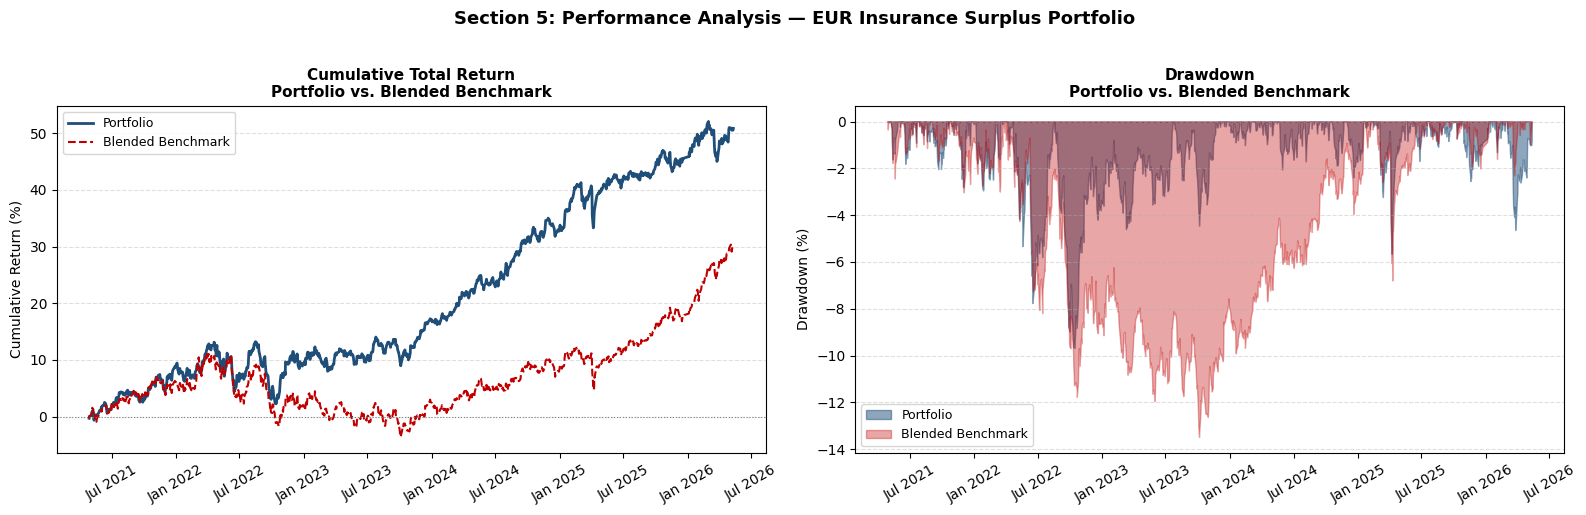

Section 5 charts saved to section5_performance.png


In [ ]:
#Performance graphs
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='white')

# Chart A — Cumulative return
cum_port  = (np.exp(port_ret_aligned.cumsum())  - 1) * 100
cum_bench = (np.exp(benchmark_returns.cumsum()) - 1) * 100

ax = axes[0]
ax.plot(cum_port.index,  cum_port,  lw=2,   color='#1f4e79', label='Portfolio')
ax.plot(cum_bench.index, cum_bench, lw=1.5, color='#c00000',
        linestyle='--', label='Blended Benchmark')
ax.axhline(0, color='grey', lw=0.8, linestyle=':')
ax.set_ylabel('Cumulative Return (%)', fontsize=10)
ax.set_title('Cumulative Total Return\nPortfolio vs. Blended Benchmark',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.tick_params(axis='x', rotation=30)
ax.set_facecolor('white')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

# Chart B — Drawdown
def drawdown_series(ret):
    cum  = np.exp(ret.cumsum())
    peak = cum.cummax()
    return (cum - peak) / peak * 100

dd_port  = drawdown_series(port_ret_aligned)
dd_bench = drawdown_series(benchmark_returns)

ax2 = axes[1]
ax2.fill_between(dd_port.index,  dd_port,  0, alpha=0.5,  color='#1f4e79', label='Portfolio')
ax2.fill_between(dd_bench.index, dd_bench, 0, alpha=0.35, color='#c00000', label='Blended Benchmark')
ax2.set_ylabel('Drawdown (%)', fontsize=10)
ax2.set_title('Drawdown\nPortfolio vs. Blended Benchmark',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.tick_params(axis='x', rotation=30)
ax2.set_facecolor('white')
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Section 5: Performance Analysis — EUR Insurance Surplus Portfolio',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('section5_performance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Section 5 charts saved to section5_performance.png')


---
## Section 6: Risk Analysis

Risk is measured using the ERC portfolio return series with a €500m NAV assumption. The following measures are computed:
1. **Portfolio volatility** — annualised standard deviation of daily log returns
2. **Adverse volatility** — downside deviation below the daily risk-free rate (Sortino denominator)
3. **Historical VaR (99%)** — empirical 1st percentile of the return distribution
4. **Parametric VaR (99%)** — normal-distribution assumption for comparison
5. **CVaR / Expected Shortfall** — average loss beyond the VaR threshold
6. **Marginal VaR** — component VaR decomposed by instrument
7. **Return distribution statistics** — skewness and excess kurtosis

In [ ]:
# Constraints
TRADING_DAYS = 252
CONFIDENCE = 0.99
RF_DAILY = RF_ANNUAL/TRADING_DAYS # MAR
PORTFOLIO_NAV = 500_000_000 # €500m portfolio


In [ ]:
# Volatility
daily_vol  = portfolio_returns.std()
annual_vol = daily_vol * np.sqrt(TRADING_DAYS)

print("=" * 55)
print("1. PORTFOLIO VOLATILITY")
print("=" * 55)
print(f"   Daily volatility:       {daily_vol:.6f}  ({daily_vol*100:.4f}%)")
print(f"   Annualised volatility:  {annual_vol:.4f}  ({annual_vol*100:.2f}%)")
print(f"\n   Interpretation: The portfolio exhibits annualised")
print(f"   volatility of {annual_vol*100:.2f}%, within the insurance mandate's")
print(f"   12% maximum volatility constraint.")

1. PORTFOLIO VOLATILITY
   Daily volatility:       0.004295  (0.4295%)
   Annualised volatility:  0.0682  (6.82%)

   Interpretation: The portfolio exhibits annualised
   volatility of 6.82%, within the insurance mandate's
   12% maximum volatility constraint.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Adverse vol (downside)
# ─────────────────────────────────────────────────────────────
# Adverse volatility = downside deviation below risk-free rate threshold (only penalises returns falling below Rf, does not reward upside)

downside_returns = portfolio_returns[portfolio_returns < RF_DAILY]
downside_deviation = np.sqrt((downside_returns - RF_DAILY).pow(2).mean()) * np.sqrt(TRADING_DAYS)

# Also compute semi-deviation (threshold = 0) for comparison
negative_returns = portfolio_returns[portfolio_returns < 0]
semi_deviation = np.sqrt(negative_returns.pow(2).mean()) * np.sqrt(TRADING_DAYS)

print("\n" + "=" * 55)
print("2. ADVERSE VOLATILITY (Downside Deviation)")
print("=" * 55)
print(f"   Threshold (Rf daily):   {RF_DAILY:.6f}")
print(f"   Downside observations:  {len(downside_returns)} of {len(portfolio_returns)} days")
print(f"   Downside deviation:     {downside_deviation*100:.2f}% (annualised)")
print(f"   Semi-deviation (0%):    {semi_deviation*100:.2f}% (annualised)")
print(f"   Total volatility:       {annual_vol*100:.2f}% (annualised)")
print(f"\n   Interpretation: Adverse volatility of {downside_deviation*100:.2f}% is")
print(f"   {'lower' if downside_deviation < annual_vol else 'higher'} than total volatility ({annual_vol*100:.2f}%), indicating the")
print(f"   portfolio's downside risk profile is {'favourable' if downside_deviation < annual_vol else 'skewed negatively'}.")
print(f"   The Sortino ratio denominator uses this measure.")


2. ADVERSE VOLATILITY (Downside Deviation)
   Threshold (Rf daily):   0.000077
   Downside observations:  542 of 1225 days
   Downside deviation:     7.35% (annualised)
   Semi-deviation (0%):    7.34% (annualised)
   Total volatility:       6.82% (annualised)

   Interpretation: Adverse volatility of 7.35% is
   higher than total volatility (6.82%), indicating the
   portfolio's downside risk profile is skewed negatively.
   The Sortino ratio denominator uses this measure.


In [ ]:
# ─────────────────────────────────────────────────────────────
# 99% Historical VaR
# ─────────────────────────────────────────────────────────────
# Historical simulation — no distributional assumption
# Uses full empirical return distribution

var_pct_hist   = np.percentile(portfolio_returns, (1 - CONFIDENCE) * 100)
var_gbp_hist   = abs(var_pct_hist) * PORTFOLIO_NAV

# Annual VaR (scaled — note this is approximate, square root of time)
var_annual_hist = var_pct_hist * np.sqrt(TRADING_DAYS)

print("\n" + "=" * 55)
print("3. VALUE-AT-RISK (99% Confidence Level)")
print("=" * 55)
print(f"\n--- Historical Simulation ---")
print(f"99% Daily VaR: {var_pct_hist*100:.4f}%")
print(f"99% Daily VaR (€): €{var_gbp_hist:,.0f}")
print(f"nterpretation: On any given day, there is a 1%")
print(f"probability that the portfolio loses more than")
print(f"{abs(var_pct_hist)*100:.2f}% (€{var_gbp_hist:,.0f}) of its value.")


3. VALUE-AT-RISK (99% Confidence Level)

--- Historical Simulation ---
99% Daily VaR: -1.1327%
99% Daily VaR (€): €5,663,304
nterpretation: On any given day, there is a 1%
probability that the portfolio loses more than
1.13% (€5,663,304) of its value.


In [ ]:
# ─────────────────────────────────────────────────────────────
# 99% Param VaR (comp)
# ─────────────────────────────────────────────────────────────
# Assumes normally distributed returns

z_score = stats.norm.ppf(1 - CONFIDENCE)
var_pct_param = -(portfolio_returns.mean() + z_score * daily_vol)
var_gbp_param = abs(var_pct_param) * PORTFOLIO_NAV

print(f"\n--- Parametric (Normal Distribution) ---")
print(f"99% Daily VaR: {var_pct_param*100:.4f}%")
print(f"99% Daily VaR (€): €{var_gbp_param:,.0f}")

# Compare the two
diff = abs(var_pct_hist) - abs(var_pct_param)
print(f"\n--- Comparison ---")
print(f"Historical VaR: {abs(var_pct_hist)*100:.4f}%")
print(f"Parametric VaR: {abs(var_pct_param)*100:.4f}%")
print(f"Difference: {diff*100:.4f}%")
if abs(var_pct_hist) > abs(var_pct_param):
    print(f"\nInterpretation: Historical VaR exceeds parametric VaR")
    print(f"by {diff*100:.4f}%, indicating the return distribution exhibits")
    print(f"fat tails (excess kurtosis) not captured by the normal")
    print(f"distribution assumption. Historical simulation is therefore")
    print(f"the preferred measure for this portfolio.")
else:
    print(f"\nInterpretation: Parametric VaR slightly exceeds historical")
    print(f"VaR, suggesting near-normal return distribution.")



--- Parametric (Normal Distribution) ---
99% Daily VaR: 0.9657%
99% Daily VaR (€): €4,828,444

--- Comparison ---
Historical VaR: 1.1327%
Parametric VaR: 0.9657%
Difference: 0.1670%

Interpretation: Historical VaR exceeds parametric VaR
by 0.1670%, indicating the return distribution exhibits
fat tails (excess kurtosis) not captured by the normal
distribution assumption. Historical simulation is therefore
the preferred measure for this portfolio.


In [ ]:
# ─────────────────────────────────────────────────────────────
# 99% CVaR, expected shortfall
# ─────────────────────────────────────────────────────────────
# CVaR = mean of all returns worse than VaR threshold, more informative than VaR (tells you the expected loss given breach)

tail_returns  = portfolio_returns[portfolio_returns <= var_pct_hist]
cvar_pct = tail_returns.mean()
cvar_gbp = abs(cvar_pct) * PORTFOLIO_NAV

print("\n" + "=" * 55)
print("4. CVaR / EXPECTED SHORTFALL (99%)")
print("=" * 55)
print(f"   Tail observations:      {len(tail_returns)} days")
print(f"   99% CVaR (daily):       {cvar_pct*100:.4f}%")
print(f"   99% CVaR (€):           €{cvar_gbp:,.0f}")
print(f"   VaR/CVaR ratio:         {abs(cvar_pct)/abs(var_pct_hist):.3f}x")
print(f"\n   Interpretation: In the worst 1% of trading days,")
print(f"   the portfolio is expected to lose {abs(cvar_pct)*100:.2f}% on average")
print(f"   (€{cvar_gbp:,.0f}), which is {abs(cvar_pct)/abs(var_pct_hist):.2f}x the VaR threshold.")
print(f"   CVaR is the preferred tail risk measure under Solvency II")
print(f"   internal model frameworks as it captures severity beyond VaR.")


4. CVaR / EXPECTED SHORTFALL (99%)
   Tail observations:      13 days
   99% CVaR (daily):       -1.5997%
   99% CVaR (€):           €7,998,596
   VaR/CVaR ratio:         1.412x

   Interpretation: In the worst 1% of trading days,
   the portfolio is expected to lose 1.60% on average
   (€7,998,596), which is 1.41x the VaR threshold.
   CVaR is the preferred tail risk measure under Solvency II
   internal model frameworks as it captures severity beyond VaR.


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Marginal VaR by instrument
# ─────────────────────────────────────────────────────────────
# Marginal VaR = sensitivity of portfolio VaR to a small increase in each instrument's weight
# Computed as: weight_i * correlation(i, portfolio) * portfolio_vol * z

print("\n" + "=" * 55)
print("5. MARGINAL VaR BY INSTRUMENT")
print("=" * 55)

marginal_var_results = []

for instrument in WEIGHTS.keys():
    w_i = WEIGHTS[instrument]
    returns_i  = df[instrument]

    # Correlation of instrument with portfolio
    corr_i = returns_i.corr(portfolio_returns)

    # Component VaR = w_i * corr_i * portfolio_vol * z * NAV
    component_var_pct = w_i * corr_i * daily_vol * abs(z_score)
    component_var_eur = component_var_pct * PORTFOLIO_NAV

    # % contribution to total VaR
    var_contribution_pct = component_var_pct / abs(var_pct_param) * 100

    marginal_var_results.append({
        "Instrument":       instrument.replace(" Equity", ""),
        "Weight":           f"{w_i*100:.0f}%",
        "Corr w/ Portfolio":f"{corr_i:.3f}",
        "Component VaR %":  round(component_var_pct * 100, 4),
        "Component VaR €M": round(component_var_eur / 1e6, 2),
        "VaR Contribution": round(var_contribution_pct, 1),
    })

mvar_df = pd.DataFrame(marginal_var_results).sort_values(
    "VaR Contribution", ascending=False
)
print(mvar_df.to_string(index=False))


5. MARGINAL VaR BY INSTRUMENT
             Instrument Weight Corr w/ Portfolio  Component VaR %  Component VaR €M  VaR Contribution
      INFR (Glob Infra)    11%             0.566           0.0641              0.32               6.6
         KO (Coca-Cola)    11%             0.567           0.0605              0.30               6.3
  IS15 (Glob Corp Bond)    14%             0.409           0.0556              0.28               5.8
   ADP (Auto Data Proc)     7%             0.605           0.0440              0.22               4.6
               V (Visa)     7%             0.597           0.0420              0.21               4.4
    ARCC (Ares Capital)     7%             0.584           0.0398              0.20               4.1
 IHYU (Glob High Yield)     7%             0.546           0.0370              0.19               3.8
      4GLD (Xetra Gold)     9%             0.289           0.0248              0.12               2.6
         IEMB (EM Bond)     5%             0.517   

In [ ]:
# ─────────────────────────────────────────────────────────────
# Distribution statistics
# ─────────────────────────────────────────────────────────────
skewness = portfolio_returns.skew()
kurtosis = portfolio_returns.kurtosis()  # excess kurtosis (normal = 0)

print("\n" + "=" * 55)
print("6. RETURN DISTRIBUTION STATISTICS")
print("=" * 55)
print(f"   Skewness:               {skewness:.4f}")
print(f"   Excess Kurtosis:        {kurtosis:.4f}")
print(f"   Min daily return:       {portfolio_returns.min()*100:.4f}%")
print(f"   Max daily return:       {portfolio_returns.max()*100:.4f}%")

if kurtosis > 1:
    print(f"\n   Fat tails confirmed (excess kurtosis = {kurtosis:.2f} > 0).")
    print(f"   This justifies using historical rather than parametric VaR.")


6. RETURN DISTRIBUTION STATISTICS
   Skewness:               -0.5986
   Excess Kurtosis:        3.6491
   Min daily return:       -2.9917%
   Max daily return:       2.1102%

   Fat tails confirmed (excess kurtosis = 3.65 > 0).
   This justifies using historical rather than parametric VaR.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("RISK METRICS SUMMARY TABLE")
print("=" * 55)
summary = {
    "Annualised Volatility":        f"{annual_vol*100:.2f}%",
    "Adverse Volatility (DD)":      f"{downside_deviation*100:.2f}%",
    "99% Historical VaR (daily)":   f"{abs(var_pct_hist)*100:.4f}%",
    "99% Historical VaR (€)":       f"€{var_gbp_hist:,.0f}",
    "99% Parametric VaR (daily)":   f"{abs(var_pct_param)*100:.4f}%",
    "99% CVaR / ES (daily)":        f"{abs(cvar_pct)*100:.4f}%",
    "99% CVaR (€)":                 f"€{cvar_gbp:,.0f}",
    "Skewness":                     f"{skewness:.4f}",
    "Excess Kurtosis":              f"{kurtosis:.4f}",
}
for k, v in summary.items():
    print(f"   {k:<35} {v}")



RISK METRICS SUMMARY TABLE
   Annualised Volatility               6.82%
   Adverse Volatility (DD)             7.35%
   99% Historical VaR (daily)          1.1327%
   99% Historical VaR (€)              €5,663,304
   99% Parametric VaR (daily)          0.9657%
   99% CVaR / ES (daily)               1.5997%
   99% CVaR (€)                        €7,998,596
   Skewness                            -0.5986
   Excess Kurtosis                     3.6491


### Extra: portfolio optimis with constrained Markowitz (mandate constraints)

In [ ]:
# Annualised return per instrument
instrument_returns = df.mean() * 252

print("Annualised return by instrument (%):")
print((instrument_returns * 100).sort_values().round(2).to_string())

Annualised return by instrument (%):
XGIG (Glob InflLink)       -1.62
IGILL (Glob InflLink)      -1.38
IEMB (EM Bond)              1.84
IS15 (Glob Corp Bond)       2.31
IHYU (Glob High Yield)      4.21
INFR (Glob Infra)           5.54
ADP (Auto Data Proc)        6.50
V (Visa)                   10.61
ARCC (Ares Capital)        10.92
KO (Coca-Cola)             12.60
WCOB (WT Enh Commodity)    14.71
3i Group (PE proxy)        18.05
4GLD (Xetra Gold)          21.75


In [ ]:
mean_returns = df.mean() * 252
cov_matrix = df.cov() * 252
n = len(df.columns)
tickers = df.columns.tolist()

RF = 0.0265

def neg_sharpe(weights):
    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(weights @ cov_matrix @ weights)
    return -(port_return - RF)/port_vol

In [ ]:
# Asset class mapping using actual df column names

asset_classes = {
    "IS15 LN Equity": "Fixed Income",
    "IGILL EB Equity": "Fixed Income",
    "XGIG LN Equity": "Fixed Income",
    "IHYU LN Equity": "Fixed Income",
    "IEMB LN Equity": "Fixed Income",

    "ADP US Equity": "Equity",
    "V US Equity": "Equity",
    "KO US Equity": "Equity",

    "INFR LN Equity": "Alternatives",
    "ARCC US Equity": "Alternatives",
    "III LN Equity": "Alternatives",

    "4GLD GY Equity": "Commodities",
    "WCOB LN Equity": "Commodities"
}

target_sleeves = {
    "Fixed Income": 0.35,
    "Equity": 0.25,
    "Alternatives": 0.225,
    "Commodities": 0.175
}


In [ ]:
# Constraints

constraints = [
    {"type": "eq", "fun": lambda w: np.sum(w) - 1}
]

# Each asset class sleeve must equal its target allocation
for sleeve, target in target_sleeves.items():
    idx = [i for i, t in enumerate(tickers) if asset_classes.get(t) == sleeve]

    constraints.append({
        "type": "eq",
        "fun": lambda w, idx=idx, target=target: np.sum(w[idx]) - target
    })

# Bounds (individual instrument bounds: 3% minimum, 15% maximum)
bounds = tuple((0.03, 0.15) for _ in range(n))


In [ ]:
# Feasible initial weights
w0 = np.zeros(n)

for sleeve, target in target_sleeves.items():
    idx = [i for i, t in enumerate(tickers) if asset_classes.get(t) == sleeve]

    if len(idx) > 0:
        for i in idx:
            w0[i] = target / len(idx)

In [ ]:
# Run optimisation
result = minimize(
    neg_sharpe,
    w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 1000, "ftol": 1e-9}
)

opt_weights = result.x
opt_return = np.dot(opt_weights, mean_returns)
opt_vol = np.sqrt(opt_weights @ cov_matrix @ opt_weights)
opt_sharpe = (opt_return - RF) / opt_vol

print("=" * 65)
print("OPTIMISED PORTFOLIO WEIGHTS (Constrained Max Sharpe)")
print("=" * 65)
print(f"{'Instrument':<30} {'Weight':>8}")
print("-" * 45)

for t, w in sorted(zip(tickers, opt_weights), key=lambda x: -x[1]):
    print(f"  {t.replace(' Equity',''):<28} {w*100:>6.2f}%")

print("-" * 45)
print(f"  {'TOTAL':<28} {sum(opt_weights)*100:>6.2f}%")

print("\nSleeve allocations:")
for sleeve in target_sleeves:
    sleeve_weight = sum(
        opt_weights[i]
        for i, t in enumerate(tickers)
        if asset_classes.get(t) == sleeve
    )
    print(f"  {sleeve:<18} {sleeve_weight*100:>6.2f}%")

print(f"\nOptimised portfolio metrics:")
print(f"  Annualised Return:  {opt_return*100:.2f}%")
print(f"  Annualised Vol:     {opt_vol*100:.2f}%")
print(f"  Sharpe Ratio:       {opt_sharpe:.3f}")
print(f"  Converged:          {result.success}")
print(f"  Message:            {result.message}")

OPTIMISED PORTFOLIO WEIGHTS (Constrained Max Sharpe)
Instrument                       Weight
---------------------------------------------
  4GLD (Xetra Gold)              3.00%
  ADP (Auto Data Proc)           3.00%
  ARCC (Ares Capital)            3.00%
  IEMB (EM Bond)                 3.00%
  IGILL (Glob InflLink)          3.00%
  IHYU (Glob High Yield)         3.00%
  3i Group (PE proxy)            3.00%
  INFR (Glob Infra)              3.00%
  IS15 (Glob Corp Bond)          3.00%
  KO (Coca-Cola)                 3.00%
  V (Visa)                       3.00%
  WCOB (WT Enh Commodity)        3.00%
  XGIG (Glob InflLink)           3.00%
---------------------------------------------
  TOTAL                         39.00%

Sleeve allocations:
  Fixed Income         0.00%
  Equity               0.00%
  Alternatives         0.00%
  Commodities          0.00%

Optimised portfolio metrics:
  Annualised Return:  3.18%
  Annualised Vol:     2.85%
  Sharpe Ratio:       0.186
  Converged:      

---
## Section 7: Scenario Analysis

Three historical and hypothetical stress scenarios are applied to the portfolio:
1. **COVID Crash (Feb–Mar 2020)** — sharp equity sell-off with flight-to-quality bond rally
2. **2022 Rate Shock (Jan–Dec 2022)** — synchronised bond and equity drawdown from aggressive monetary tightening
3. **Beta-Derived −10% Equity Decline** — hypothetical 10% fall in equities, with asset-class returns scaled by their historical beta to the equity market

For each scenario, portfolio P&L, sleeve weight drift, and implied rebalancing trades are reported. Stressed VaR (99%) is also computed conditional on each stress window.

In [ ]:
# Configuration

TRADING_DAYS     = 252
RISK_FREE_ANNUAL = 0.0265
PORTFOLIO_NAV    = 500_000_000
CONFIDENCE       = 0.99
START_DATE       = "2021-04-26"
END_DATE         = "2026-05-13"

WEIGHTS = {
    "IS15 (Glob Corp Bond)":   0.1362,
    "IGILL (Glob InflLink)":   0.0427,
    "XGIG (Glob InflLink)":    0.0551,
    "IHYU (Glob High Yield)":  0.0678,
    "IEMB (EM Bond)":          0.0482,
    "ADP (Auto Data Proc)":    0.0729,
    "V (Visa)":                0.0705,
    "KO (Coca-Cola)":          0.1066,
    "INFR (Glob Infra)":       0.1133,
    "ARCC (Ares Capital)":     0.0682,
    "3i Group (PE proxy)":     0.0434,
    "4GLD (Xetra Gold)":       0.0857,
    "WCOB (WT Enh Commodity)": 0.0893,
}

ASSET_CLASSES = {
    "IS15 (Glob Corp Bond)":   "Fixed Income",
    "IGILL (Glob InflLink)":   "Fixed Income",
    "XGIG (Glob InflLink)":    "Fixed Income",
    "IHYU (Glob High Yield)":  "Fixed Income",
    "IEMB (EM Bond)":          "Fixed Income",
    "ADP (Auto Data Proc)":    "Equity",
    "V (Visa)":                "Equity",
    "KO (Coca-Cola)":          "Equity",
    "INFR (Glob Infra)":       "Alternatives",
    "ARCC (Ares Capital)":     "Alternatives",
    "3i Group (PE proxy)":     "Alternatives",
    "4GLD (Xetra Gold)":       "Commodities",
    "WCOB (WT Enh Commodity)": "Commodities",
}

SCR_CHARGES = {
    "IS15 (Glob Corp Bond)":   0.10,
    "IGILL (Glob InflLink)":   0.05,
    "XGIG (Glob InflLink)":    0.05,
    "IHYU (Glob High Yield)":  0.25,
    "IEMB (EM Bond)":          0.18,
    "ADP (Auto Data Proc)":    0.39,
    "V (Visa)":                0.39,
    "KO (Coca-Cola)":          0.39,
    "INFR (Glob Infra)":       0.22,
    "ARCC (Ares Capital)":     0.49,
    "3i Group (PE proxy)":     0.49,
    "4GLD (Xetra Gold)":       0.35,
    "WCOB (WT Enh Commodity)": 0.35,
}

SLEEVE_WEIGHTS = {
    "Fixed Income (AGG)":   0.35,
    "Equity (URTH)":        0.25,
    "Alternatives (INFR)":  0.225,
    "Commodities (GSG)":    0.175,
}

SLEEVE_TO_BM = {
    "Fixed Income":  "Fixed Income (AGG)",
    "Equity":        "Equity (URTH)",
    "Alternatives":  "Alternatives (INFR)",
    "Commodities":   "Commodities (GSG)",
}

SLEEVE_COLORS = {
    "Fixed Income":  "#2471a3",
    "Equity":        "#7d3c98",
    "Alternatives":  "#ca6f1e",
    "Commodities":   "#1e8449",
}

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-3, "Weights must sum to 1"
print("Configuration loaded. Weights sum:", round(sum(WEIGHTS.values()), 4))

Configuration loaded. Weights sum: 0.9999


In [ ]:
# Data Loading

returns = pd.read_csv("portfolio_daily_returns.csv",
                      index_col="Date", parse_dates=True)
prices  = pd.read_csv("portfolio_daily_prices.csv",
                      index_col="Date", parse_dates=True)

weights_series    = pd.Series(WEIGHTS)
portfolio_returns = returns[list(WEIGHTS.keys())].dot(weights_series)

ann_ret = portfolio_returns.mean() * TRADING_DAYS * 100
ann_vol = portfolio_returns.std()  * np.sqrt(TRADING_DAYS) * 100
sharpe  = (portfolio_returns.mean() * TRADING_DAYS - RISK_FREE_ANNUAL) /           (portfolio_returns.std() * np.sqrt(TRADING_DAYS))

baseline_scr = sum(WEIGHTS[i] * SCR_CHARGES[i] for i in WEIGHTS)

print(f"Portfolio: {returns.shape[0]} obs | {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Annualised return:  {ann_ret:.2f}%")
print(f"Annualised vol:     {ann_vol:.2f}%")
print(f"Sharpe (Rf=2.65%):  {sharpe:.3f}")
print(f"Baseline SCR:       {baseline_scr*100:.2f}%  (EUR {baseline_scr*PORTFOLIO_NAV/1e6:.1f}m)")

Portfolio: 1225 obs | 2021-04-27 to 2026-05-12
Annualised return:  8.44%
Annualised vol:     6.82%
Sharpe (Rf=2.65%):  0.849
Baseline SCR:       28.25%  (EUR 141.2m)


In [ ]:
# Benchmark Data

BENCHMARK_TICKERS = {
    "Fixed Income (AGG)":   "AGG",
    "Equity (URTH)":        "URTH",
    "Alternatives (INFR)":  "INFR.L",
    "Commodities (GSG)":    "GSG",
}

bm_raw = yf.download(
    list(BENCHMARK_TICKERS.values()),
    start=START_DATE, end=END_DATE,
    auto_adjust=True, progress=False,
)["Close"]
bm_raw.columns = list(BENCHMARK_TICKERS.keys())

bm_prices      = bm_raw.reindex(prices.index).ffill()
bm_returns     = bm_prices.pct_change().dropna(how="all")
sleeve_w       = pd.Series(SLEEVE_WEIGHTS)
bm_ret_aligned = bm_returns.reindex(portfolio_returns.index).ffill()
blended_bm     = bm_ret_aligned.dot(sleeve_w)

print(f"Benchmarks loaded: {bm_prices.shape}")
print(f"Missing values: {bm_prices.isna().sum().to_dict()}")
print(f"Blended BM | Return: {blended_bm.mean()*TRADING_DAYS*100:.2f}%  "
      f"Vol: {blended_bm.std()*np.sqrt(TRADING_DAYS)*100:.2f}%")

Benchmarks loaded: (1226, 4)
Missing values: {'Fixed Income (AGG)': 0, 'Equity (URTH)': 0, 'Alternatives (INFR)': 0, 'Commodities (GSG)': 0}
Blended BM | Return: 8.56%  Vol: 8.17%


In [ ]:
# Scenario Engine

def run_scenario(name, shocks_by_class, inst_shocks=None):
    results = []
    for inst in WEIGHTS:
        shock = inst_shocks[inst] if inst_shocks else shocks_by_class[ASSET_CLASSES[inst]]
        results.append({
            "Instrument":       inst,
            "Asset Class":      ASSET_CLASSES[inst],
            "Weight (%)":       round(WEIGHTS[inst] * 100, 2),
            "Shock (%)":        round(shock * 100, 2),
            "Contribution (%)": round(WEIGHTS[inst] * shock * 100, 4),
        })

    df = pd.DataFrame(results).sort_values("Contribution (%)")
    port_stressed = df["Contribution (%)"].sum()

    bm_stressed = sum(
        SLEEVE_WEIGHTS[SLEEVE_TO_BM[cls]] * shock
        for cls, shock in shocks_by_class.items()
    ) * 100

    post_vals = {
        inst: WEIGHTS[inst] * (1 + (inst_shocks[inst] if inst_shocks
                                     else shocks_by_class[ASSET_CLASSES[inst]]))
        for inst in WEIGHTS
    }
    total   = sum(post_vals.values())
    drifted = {inst: post_vals[inst] / total for inst in WEIGHTS}

    stressed_scr = sum(drifted[i] * SCR_CHARGES[i] for i in WEIGHTS)
    scr_delta    = stressed_scr - baseline_scr

    print(f"{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"\nShock assumptions:")
    for cls, shock in shocks_by_class.items():
        print(f"  {cls:<22} {shock*100:+.2f}%")
    print(f"\nPortfolio stressed return:   {port_stressed:.4f}%"
          f"  (EUR {abs(port_stressed/100)*PORTFOLIO_NAV/1e6:.1f}m loss)")
    print(f"Benchmark stressed return:   {bm_stressed:.4f}%")
    print(f"Outperformance (alpha):      {port_stressed - bm_stressed:+.4f}%")
    print(f"\nSolvency II SCR:")
    print(f"  Pre-shock:  {baseline_scr*100:.2f}%  (EUR {baseline_scr*PORTFOLIO_NAV/1e6:.1f}m)")
    print(f"  Post-shock: {stressed_scr*100:.2f}%  (EUR {stressed_scr*PORTFOLIO_NAV/1e6:.1f}m)")
    print(f"  Delta:      {scr_delta*100:+.2f}pp")
    print(f"\nSleeve drift:")
    for sleeve in ["Fixed Income", "Equity", "Alternatives", "Commodities"]:
        orig  = sum(WEIGHTS[i] for i in WEIGHTS if ASSET_CLASSES[i] == sleeve) * 100
        drift = sum(drifted[i] for i in WEIGHTS  if ASSET_CLASSES[i] == sleeve) * 100
        print(f"  {sleeve:<22} {orig:.2f}% -> {drift:.2f}%  ({drift-orig:+.2f}pp)")

    return df, port_stressed, bm_stressed, drifted, stressed_scr

print("Scenario engine ready.")

Scenario engine ready.


In [ ]:
# Correlation breakdown analysis

STRESS_WINDOWS = {
    "S2: Rate Shock (Jan-Dec 2022)": ("2022-01-03", "2022-12-30"),
    "Normal (Full Sample)":          (START_DATE,   END_DATE),
}

sleeves = ["Fixed Income", "Equity", "Alternatives", "Commodities"]
sleeve_returns = {}
for sleeve in sleeves:
    insts   = [i for i in WEIGHTS if ASSET_CLASSES[i] == sleeve]
    total_w = sum(WEIGHTS[i] for i in insts)
    sleeve_returns[sleeve] = sum(returns[i] * (WEIGHTS[i] / total_w) for i in insts)

sleeve_ret_df = pd.DataFrame(sleeve_returns)

corr_matrices = {}
for label, (start, end) in STRESS_WINDOWS.items():
    window = sleeve_ret_df.loc[start:end]
    corr_matrices[label] = window.corr()
    print(f"\n{'─'*55}")
    print(f"Correlation matrix — {label}")
    print(f"{'─'*55}")
    print(window.corr().round(3).to_string())

print(f"\n{'='*55}")
print("Diversification Ratio by Window")
print(f"{'='*55}")
for label, (start, end) in STRESS_WINDOWS.items():
    port_w = sleeve_ret_df.loc[start:end].dot(
        pd.Series({s: sum(WEIGHTS[i] for i in WEIGHTS if ASSET_CLASSES[i] == s)
                   for s in sleeves})
    )
    port_vol         = port_w.std()
    sleeve_vols      = sleeve_ret_df.loc[start:end].std()
    sleeve_w_arr     = np.array([sum(WEIGHTS[i] for i in WEIGHTS
                                     if ASSET_CLASSES[i] == s) for s in sleeves])
    weighted_avg_vol = np.dot(sleeve_w_arr, sleeve_vols.values)
    dr = weighted_avg_vol / port_vol if port_vol > 0 else np.nan
    print(f"  {label:<35} DR = {dr:.3f}")

print("\nNote: COVID window excluded — data starts Apr 2021, after the crash.")
print("DR > 1 = diversification benefit exists. DR falling = correlations spiked.")


───────────────────────────────────────────────────────
Correlation matrix — S2: Rate Shock (Jan-Dec 2022)
───────────────────────────────────────────────────────
              Fixed Income  Equity  Alternatives  Commodities
Fixed Income         1.000   0.378         0.425       -0.027
Equity               0.378   1.000         0.555       -0.203
Alternatives         0.425   0.555         1.000       -0.027
Commodities         -0.027  -0.203        -0.027        1.000

───────────────────────────────────────────────────────
Correlation matrix — Normal (Full Sample)
───────────────────────────────────────────────────────
              Fixed Income  Equity  Alternatives  Commodities
Fixed Income         1.000   0.234         0.356        0.008
Equity               0.234   1.000         0.428       -0.089
Alternatives         0.356   0.428         1.000        0.075
Commodities          0.008  -0.089         0.075        1.000

Diversification Ratio by Window
  S2: Rate Shock (Jan-Dec 20

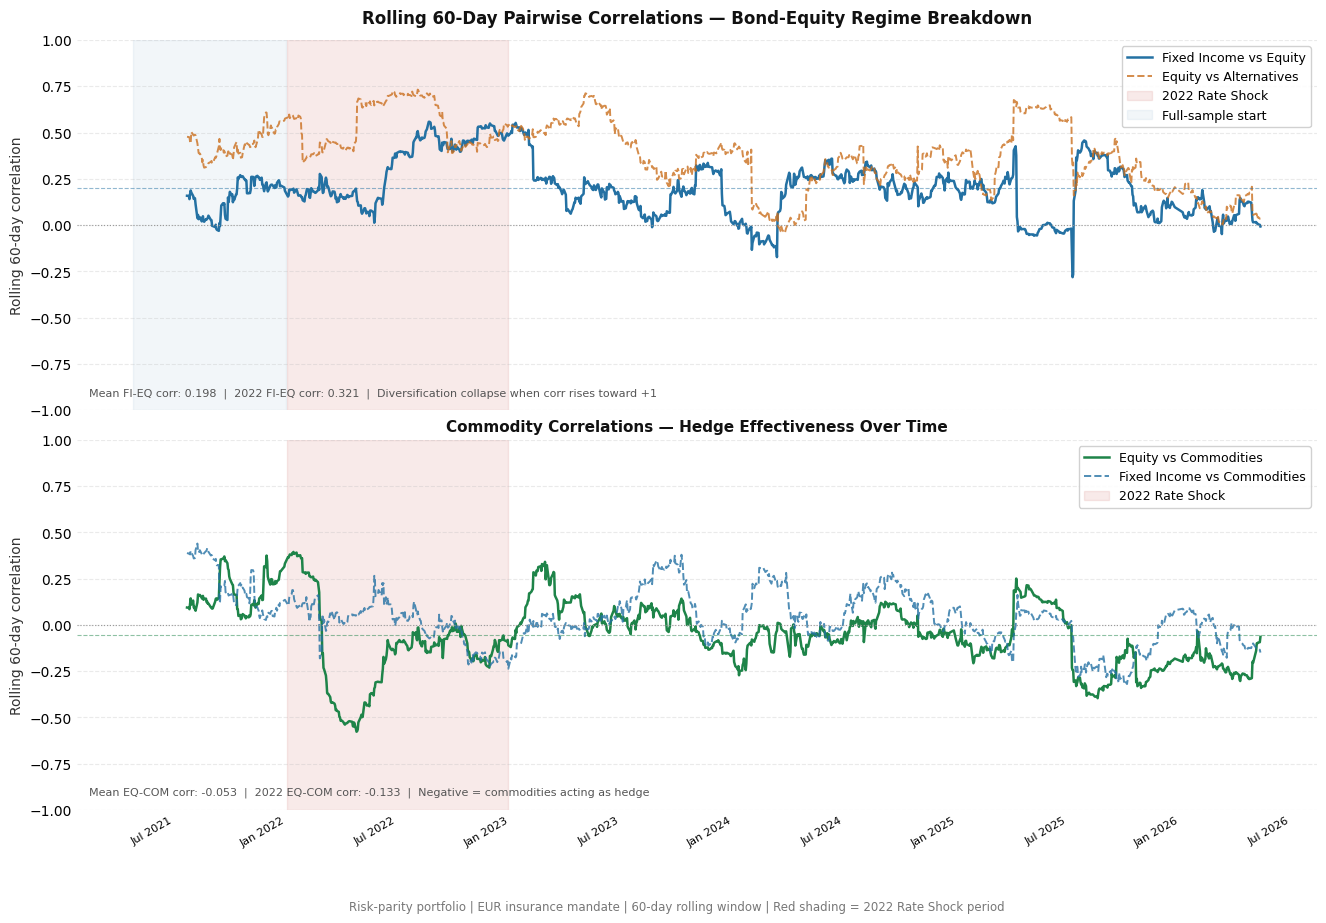

Chart 3 saved.


In [ ]:
# Chart: Rolling 60-Day Correlation: Bond-Equity Regime Breakdown

# ── Compute sleeve return series ─────────────────────────────────────
fi_ret  = sleeve_ret_df["Fixed Income"]
eq_ret  = sleeve_ret_df["Equity"]
alt_ret = sleeve_ret_df["Alternatives"]
com_ret = sleeve_ret_df["Commodities"]

WINDOW = 60

roll_fi_eq  = fi_ret.rolling(WINDOW).corr(eq_ret)
roll_fi_com = fi_ret.rolling(WINDOW).corr(com_ret)
roll_eq_com = eq_ret.rolling(WINDOW).corr(com_ret)
roll_eq_alt = eq_ret.rolling(WINDOW).corr(alt_ret)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), facecolor="white",
                         sharex=True)
fig.subplots_adjust(hspace=0.08)

# ── Top panel: Fixed Income vs Equity ────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("white")
ax1.plot(roll_fi_eq.index, roll_fi_eq,
         color=SLEEVE_COLORS["Fixed Income"], linewidth=1.8,
         label="Fixed Income vs Equity")
ax1.plot(roll_eq_alt.index, roll_eq_alt,
         color=SLEEVE_COLORS["Alternatives"], linewidth=1.4,
         linestyle="--", label="Equity vs Alternatives", alpha=0.8)
ax1.axhline(0, color="#999", linewidth=0.8, linestyle=":")
ax1.axhline(roll_fi_eq.mean(), color=SLEEVE_COLORS["Fixed Income"],
            linewidth=0.8, linestyle="--", alpha=0.5)

ax1.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-12-30"),
            alpha=0.10, color="#c0392b", label="2022 Rate Shock")
ax1.axvspan(pd.Timestamp("2021-04-26"), pd.Timestamp("2021-12-31"),
            alpha=0.06, color="#2471a3", label="Full-sample start")

ax1.set_ylabel("Rolling 60-day correlation", fontsize=10, color="#333")
ax1.set_ylim(-1, 1)
ax1.legend(fontsize=9, loc="upper right", framealpha=0.9, facecolor="white")
ax1.set_title(
    "Rolling 60-Day Pairwise Correlations — Bond-Equity Regime Breakdown",
    fontsize=12, fontweight="bold", color="#111", pad=12
)
ax1.text(0.01, 0.04,
         f"Mean FI-EQ corr: {roll_fi_eq.mean():.3f}  |  "
         f"2022 FI-EQ corr: {roll_fi_eq.loc['2022'].mean():.3f}  |  "
         f"Diversification collapse when corr rises toward +1",
         transform=ax1.transAxes, fontsize=8, color="#555")
ax1.yaxis.grid(True, linestyle="--", alpha=0.3, color="#bbb")
ax1.tick_params(length=0)

# ── Bottom panel: Equity vs Commodities ──────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("white")
ax2.plot(roll_eq_com.index, roll_eq_com,
         color=SLEEVE_COLORS["Commodities"], linewidth=1.8,
         label="Equity vs Commodities")
ax2.plot(roll_fi_com.index, roll_fi_com,
         color=SLEEVE_COLORS["Fixed Income"], linewidth=1.4,
         linestyle="--", label="Fixed Income vs Commodities", alpha=0.8)
ax2.axhline(0, color="#999", linewidth=0.8, linestyle=":")
ax2.axhline(roll_eq_com.mean(), color=SLEEVE_COLORS["Commodities"],
            linewidth=0.8, linestyle="--", alpha=0.5)

ax2.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-12-30"),
            alpha=0.10, color="#c0392b", label="2022 Rate Shock")

ax2.set_ylabel("Rolling 60-day correlation", fontsize=10, color="#333")
ax2.set_ylim(-1, 1)
ax2.legend(fontsize=9, loc="upper right", framealpha=0.9, facecolor="white")
ax2.set_title("Commodity Correlations — Hedge Effectiveness Over Time",
              fontsize=11, fontweight="bold", color="#111")
ax2.text(0.01, 0.04,
         f"Mean EQ-COM corr: {roll_eq_com.mean():.3f}  |  "
         f"2022 EQ-COM corr: {roll_eq_com.loc['2022'].mean():.3f}  |  "
         f"Negative = commodities acting as hedge",
         transform=ax2.transAxes, fontsize=8, color="#555")
ax2.yaxis.grid(True, linestyle="--", alpha=0.3, color="#bbb")
ax2.tick_params(length=0)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.patch.set_facecolor("white")
fig.text(0.5, 0.01,
         "Risk-parity portfolio | EUR insurance mandate | 60-day rolling window | "
         "Red shading = 2022 Rate Shock period",
         ha="center", fontsize=8.5, color="#777")

plt.savefig("chart3_rolling_corr.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Chart 3 saved.")

In [ ]:
# Scenario 1: COVID Crash (Feb–Mar 2020)

bm_covid_raw = yf.download(
    list(BENCHMARK_TICKERS.values()),
    start="2020-02-20", end="2020-03-23",
    auto_adjust=True, progress=False,
)["Close"]
bm_covid_raw.columns = list(BENCHMARK_TICKERS.keys())
bm_covid_ret = (bm_covid_raw.iloc[-1] / bm_covid_raw.iloc[0]) - 1

print("Realised benchmark returns — COVID crash (Feb 20 to Mar 23 2020):")
for bm, ret in bm_covid_ret.items():
    print(f"  {bm:<30} {ret*100:+.2f}%")

S1_SHOCKS = {
    "Fixed Income":  bm_covid_ret["Fixed Income (AGG)"],
    "Equity":        bm_covid_ret["Equity (URTH)"],
    "Alternatives":  bm_covid_ret["Alternatives (INFR)"],
    "Commodities":   bm_covid_ret["Commodities (GSG)"],
}

s1_df, s1_port, s1_bm, s1_drifted, s1_scr = run_scenario(
    "SCENARIO 1 — COVID CRASH (Feb 20 to Mar 23 2020)", S1_SHOCKS
)

Realised benchmark returns — COVID crash (Feb 20 to Mar 23 2020):
  Fixed Income (AGG)             -3.85%
  Equity (URTH)                  -35.30%
  Alternatives (INFR)            -20.78%
  Commodities (GSG)              -32.45%
SCENARIO 1 — COVID CRASH (Feb 20 to Mar 23 2020)

Shock assumptions:
  Fixed Income           -3.85%
  Equity                 -35.30%
  Alternatives           -20.78%
  Commodities            -32.45%

Portfolio stressed return:   -20.5259%  (EUR 102.6m loss)
Benchmark stressed return:   -20.5280%
Outperformance (alpha):      +0.0021%

Solvency II SCR:
  Pre-shock:  28.25%  (EUR 141.2m)
  Post-shock: 26.42%  (EUR 132.1m)
  Delta:      -1.83pp

Sleeve drift:
  Fixed Income           35.00% -> 42.35%  (+7.35pp)
  Equity                 25.00% -> 20.35%  (-4.65pp)
  Alternatives           22.49% -> 22.42%  (-0.07pp)
  Commodities            17.50% -> 14.88%  (-2.62pp)


In [ ]:
# Scenario 2: 2022 Rate Shock (Jan–Dec 2022)

BENCHMARK_TICKERS_S2 = {
    "AGG":  "Fixed Income (AGG)",
    "ACWI": "Equity (URTH)",
    "IGF":  "Alternatives (INFR)",
    "GSG":  "Commodities (GSG)",
}

bm_rate_raw = yf.download(
    list(BENCHMARK_TICKERS_S2.keys()),
    start="2022-01-03", end="2022-12-30",
    auto_adjust=True, progress=False,
)["Close"]
bm_rate_raw = bm_rate_raw.rename(columns=BENCHMARK_TICKERS_S2)
bm_rate_ret = (bm_rate_raw.iloc[-1] / bm_rate_raw.iloc[0]) - 1

print("Realised benchmark returns — 2022 Rate Shock (Jan to Dec 2022):")
for bm, ret in bm_rate_ret.items():
    print(f"  {bm:<30} {ret*100:+.2f}%")

S2_SHOCKS = {
    "Fixed Income":  bm_rate_ret["Fixed Income (AGG)"],
    "Equity":        bm_rate_ret["Equity (URTH)"],
    "Alternatives":  bm_rate_ret["Alternatives (INFR)"],
    "Commodities":   bm_rate_ret["Commodities (GSG)"],
}

s2_df, s2_port, s2_bm, s2_drifted, s2_scr = run_scenario(
    "SCENARIO 2 — 2022 RATE SHOCK (Jan to Dec 2022)", S2_SHOCKS
)

Realised benchmark returns — 2022 Rate Shock (Jan to Dec 2022):
  Equity (URTH)                  -18.33%
  Fixed Income (AGG)             -12.01%
  Commodities (GSG)              +22.18%
  Alternatives (INFR)            -0.72%
SCENARIO 2 — 2022 RATE SHOCK (Jan to Dec 2022)

Shock assumptions:
  Fixed Income           -12.01%
  Equity                 -18.33%
  Alternatives           -0.72%
  Commodities            +22.18%

Portfolio stressed return:   -5.0659%  (EUR 25.3m loss)
Benchmark stressed return:   -5.0661%
Outperformance (alpha):      +0.0002%

Solvency II SCR:
  Pre-shock:  28.25%  (EUR 141.2m)
  Post-shock: 28.69%  (EUR 143.4m)
  Delta:      +0.44pp

Sleeve drift:
  Fixed Income           35.00% -> 32.44%  (-2.56pp)
  Equity                 25.00% -> 21.51%  (-3.49pp)
  Alternatives           22.49% -> 23.52%  (+1.03pp)
  Commodities            17.50% -> 22.52%  (+5.02pp)


In [ ]:
# Scenario 3: Beta-Derived −10% Equity Decline

BENCHMARK_SHOCKS = {
    "Fixed Income (AGG)":   -0.04,
    "Equity (URTH)":        -0.10,
    "Alternatives (INFR)":  -0.07,
    "Commodities (GSG)":    -0.05,
}

ols_results = {}
for inst in WEIGHTS:
    sleeve   = ASSET_CLASSES[inst]
    bm_label = SLEEVE_TO_BM[sleeve]
    y = returns[inst].dropna()
    x = bm_ret_aligned[bm_label].dropna()
    common = y.index.intersection(x.index)
    slope, intercept, r, p, se = stats.linregress(x.loc[common], y.loc[common])
    ols_results[inst] = {
        "beta":    round(slope, 4),
        "r2":      round(r**2, 4),
        "p_value": round(p, 4),
        "se":      round(se, 4),
        "alpha":   round(intercept * TRADING_DAYS * 100, 4),
    }

print(f"{'Instrument':<30} {'beta':>7} {'R2':>7} {'p-val':>8} {'SE':>8} {'alpha%':>9}")
print("-" * 75)
for inst, res in ols_results.items():
    sig = "***" if res["p_value"] < 0.01 else ("**" if res["p_value"] < 0.05 else
          ("*" if res["p_value"] < 0.10 else "  "))
    print(f"  {inst:<28} {res['beta']:>7.3f} {res['r2']:>7.3f} "
          f"{res['p_value']:>8.4f}{sig} {res['se']:>8.4f} {res['alpha']:>9.2f}%")
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.10")
print("Low R2 for 4GLD and WCOB: beta unreliable — noted in methodology.")

S3_SHOCKS_INST = {
    inst: ols_results[inst]["beta"] * BENCHMARK_SHOCKS[SLEEVE_TO_BM[ASSET_CLASSES[inst]]]
    for inst in WEIGHTS
}

S3_SHOCKS = {}
for sleeve in ["Fixed Income", "Equity", "Alternatives", "Commodities"]:
    insts   = [i for i in WEIGHTS if ASSET_CLASSES[i] == sleeve]
    total_w = sum(WEIGHTS[i] for i in insts)
    S3_SHOCKS[sleeve] = sum((WEIGHTS[i] / total_w) * S3_SHOCKS_INST[i] for i in insts)

s3_results = []
for inst in WEIGHTS:
    shock = S3_SHOCKS_INST[inst]
    s3_results.append({
        "Instrument":       inst,
        "Asset Class":      ASSET_CLASSES[inst],
        "Weight (%)":       round(WEIGHTS[inst] * 100, 2),
        "beta":             ols_results[inst]["beta"],
        "R2":               ols_results[inst]["r2"],
        "p-value":          ols_results[inst]["p_value"],
        "Shock (%)":        round(shock * 100, 2),
        "Contribution (%)": round(WEIGHTS[inst] * shock * 100, 4),
    })

s3_df = pd.DataFrame(s3_results).sort_values("Contribution (%)")

s3_post_vals = {inst: WEIGHTS[inst] * (1 + S3_SHOCKS_INST[inst]) for inst in WEIGHTS}
s3_total     = sum(s3_post_vals.values())
s3_drifted   = {inst: s3_post_vals[inst] / s3_total for inst in WEIGHTS}
s3_scr       = sum(s3_drifted[i] * SCR_CHARGES[i] for i in WEIGHTS)
s3_port      = s3_df["Contribution (%)"].sum()
s3_bm        = sum(
    SLEEVE_WEIGHTS[SLEEVE_TO_BM[cls]] * BENCHMARK_SHOCKS[SLEEVE_TO_BM[cls]]
    for cls in ["Fixed Income", "Equity", "Alternatives", "Commodities"]
) * 100

print(f"\n{'='*60}")
print("SCENARIO 3 — BETA-DERIVED -10% EQUITY DECLINE")
print(f"{'='*60}")
print(s3_df.to_string(index=False))
print(f"\nPortfolio stressed return:  {s3_port:.4f}%")
print(f"Benchmark stressed return:  {s3_bm:.4f}%")
print(f"Outperformance (alpha):     {s3_port - s3_bm:+.4f}%")
print(f"\nSolvency II SCR:")
print(f"  Pre-shock:  {baseline_scr*100:.2f}%")
print(f"  Post-shock: {s3_scr*100:.2f}%")
print(f"  Delta:      {(s3_scr-baseline_scr)*100:+.2f}pp")
print("\nSleeve drift:")
for sleeve in ["Fixed Income", "Equity", "Alternatives", "Commodities"]:
    orig  = sum(WEIGHTS[i] for i in WEIGHTS if ASSET_CLASSES[i] == sleeve) * 100
    drift = sum(s3_drifted[i] for i in WEIGHTS if ASSET_CLASSES[i] == sleeve) * 100
    print(f"  {sleeve:<22} {orig:.2f}% -> {drift:.2f}%  ({drift-orig:+.2f}pp)")

Instrument                        beta      R2    p-val       SE    alpha%
---------------------------------------------------------------------------
  IS15 (Glob Corp Bond)          0.255   0.226   0.0000***   0.0135      2.23%
  IGILL (Glob InflLink)          0.984   0.383   0.0000***   0.0357     -1.69%
  XGIG (Glob InflLink)           0.783   0.355   0.0000***   0.0302     -1.87%
  IHYU (Glob High Yield)         0.464   0.173   0.0000***   0.0290      4.06%
  IEMB (EM Bond)                 0.815   0.314   0.0000***   0.0345      1.58%
  ADP (Auto Data Proc)           0.104   0.011   0.0002***   0.0276      4.43%
  V (Visa)                       0.089   0.008   0.0022***   0.0290      8.84%
  KO (Coca-Cola)                 0.029   0.002   0.1620     0.0205     12.03%
  INFR (Glob Infra)              1.000   1.000   0.0000***   0.0000     -0.00%
  ARCC (Ares Capital)            0.257   0.025   0.0000***   0.0461      9.49%
  3i Group (PE proxy)            0.578   0.056   0.0000***  

In [ ]:
# Stressed VaR (99%): Conditional on Stress Windows

# ── Normal-period VaR (full sample, historical simulation) ───────────
z_score       = stats.norm.ppf(1 - CONFIDENCE)
daily_vol     = portfolio_returns.std()
var_hist_norm = np.percentile(portfolio_returns, (1 - CONFIDENCE) * 100)
var_param_norm= z_score * daily_vol
cvar_norm     = portfolio_returns[portfolio_returns <= var_hist_norm].mean()

# ── Stressed VaR: use only returns from the 2022 stress window ────────
# (COVID window not available — data starts Apr 2021)
stress_rets_s2 = portfolio_returns.loc["2022-01-03":"2022-12-30"]

var_hist_s2  = np.percentile(stress_rets_s2, (1 - CONFIDENCE) * 100)
daily_vol_s2 = stress_rets_s2.std()
var_param_s2 = z_score * daily_vol_s2
cvar_s2      = stress_rets_s2[stress_rets_s2 <= var_hist_s2].mean()

# ── Stressed VaR: use S3 beta-shocked distribution ───────────────────
# Shift the historical distribution by the S3 stressed return
s3_shift     = s3_port / 100
shifted_rets = portfolio_returns + s3_shift
var_hist_s3  = np.percentile(shifted_rets, (1 - CONFIDENCE) * 100)
var_param_s3 = z_score * shifted_rets.std()
cvar_s3      = shifted_rets[shifted_rets <= var_hist_s3].mean()

print(f"{'='*70}")
print("STRESSED VALUE-AT-RISK — 99% CONFIDENCE (DAILY)")
print(f"{'='*70}")
print(f"{'':30} {'Hist VaR':>10} {'Param VaR':>10} {'CVaR/ES':>10} {'VaR EUR m':>12}")
print("-" * 70)

rows = [
    ("Normal (full sample)",     var_hist_norm,  var_param_norm,  cvar_norm),
    ("S2: 2022 Rate Shock",      var_hist_s2,    var_param_s2,    cvar_s2),
    ("S3: Beta-shifted dist.",   var_hist_s3,    var_param_s3,    cvar_s3),
]
for name, vh, vp, cv in rows:
    eur = abs(vh) * PORTFOLIO_NAV / 1e6
    print(f"  {name:<28} {vh*100:>9.4f}% {vp*100:>9.4f}% {cv*100:>9.4f}% {eur:>11.1f}m")

print(f"\nNormal historical VaR interpretation:")
print(f"  On any given day, 1% chance of losing > {abs(var_hist_norm)*100:.4f}%")
print(f"  (EUR {abs(var_hist_norm)*PORTFOLIO_NAV/1e6:.1f}m on EUR {PORTFOLIO_NAV/1e6:.0f}m portfolio)")
print(f"\nStressed VaR (S2) interpretation:")
print(f"  During 2022 rate shock, 1% daily loss exceeded {abs(var_hist_s2)*100:.4f}%")
print(f"  — {abs(var_hist_s2)/abs(var_hist_norm):.1f}x larger than normal-period VaR")
print(f"\nCVaR (Expected Shortfall) — loss given VaR breach:")
print(f"  Normal CVaR:  {abs(cvar_norm)*100:.4f}% | "
      f"S2 CVaR: {abs(cvar_s2)*100:.4f}% | "
      f"S3 CVaR: {abs(cvar_s3)*100:.4f}%")

STRESSED VALUE-AT-RISK — 99% CONFIDENCE (DAILY)
                                 Hist VaR  Param VaR    CVaR/ES    VaR EUR m
----------------------------------------------------------------------
  Normal (full sample)           -1.1325%   -0.9990%   -1.5995%         5.7m
  S2: 2022 Rate Shock            -1.6616%   -1.4229%   -1.8287%         8.3m
  S3: Beta-shifted dist.         -3.1141%   -0.9990%   -3.5811%        15.6m

Normal historical VaR interpretation:
  On any given day, 1% chance of losing > 1.1325%
  (EUR 5.7m on EUR 500m portfolio)

Stressed VaR (S2) interpretation:
  During 2022 rate shock, 1% daily loss exceeded 1.6616%
  — 1.5x larger than normal-period VaR

CVaR (Expected Shortfall) — loss given VaR breach:
  Normal CVaR:  1.5995% | S2 CVaR: 1.8287% | S3 CVaR: 3.5811%


In [ ]:
# Maximum Drawdown Analysis

def max_drawdown(ret_series):
    """Compute peak-to-trough maximum drawdown and recovery stats."""
    cum         = (1 + ret_series).cumprod()
    rolling_max = cum.cummax()
    drawdown    = (cum - rolling_max) / rolling_max
    max_dd      = drawdown.min()
    max_dd_date = drawdown.idxmin()
    peak_date   = cum.loc[:max_dd_date].idxmax()

    trough_val  = cum.loc[max_dd_date]
    peak_val    = rolling_max.loc[max_dd_date]
    post_trough = cum.loc[max_dd_date:]
    recovered   = post_trough[post_trough >= peak_val]

    recovery_date = recovered.index[0] if len(recovered) > 0 else None
    recovery_days = (recovery_date - max_dd_date).days if recovery_date else None

    daily_mean = ret_series.mean()
    if daily_mean > 0 and trough_val > 0 and peak_val > trough_val:
        days_to_recover = int(np.ceil(
            np.log(peak_val / trough_val) / np.log(1 + daily_mean)
        ))
    else:
        days_to_recover = None

    return {
        "Max Drawdown (%)":                   round(max_dd * 100, 4),
        "Peak Date":                          str(peak_date.date()),
        "Trough Date":                        str(max_dd_date.date()),
        "Recovery Date":                      str(recovery_date.date()) if recovery_date else "Not yet",
        "Recovery Days (calendar)":           recovery_days if recovery_days else "Not yet",
        "Est. Days to Recover (at hist avg)": days_to_recover if days_to_recover else "N/A (negative mean return in window)",
    }

# ── Windows — Full Sample and S2 only ────────────────────────────────
# S2 uses extended window including recovery period (not just 2022)
dd_windows = {
    "Full Sample":                    portfolio_returns,
    "S2: 2022 Rate Shock (extended)": portfolio_returns.loc["2022-01-03":],
}

print(f"{'='*65}")
print("MAXIMUM DRAWDOWN ANALYSIS")
print(f"{'='*65}")
for window_name, ret_series in dd_windows.items():
    dd_stats = max_drawdown(ret_series)
    print(f"\n{window_name}")
    print("-" * 50)
    for k, v in dd_stats.items():
        print(f"  {k:<45} {v}")

# ── Per-scenario drawdown using the stressed return as a one-period shock ──
print(f"\n{'='*65}")
print("SCENARIO DRAWDOWN — STRESSED SINGLE-PERIOD LOSS")
print(f"{'='*65}")
print(f"{'Scenario':<30} {'Stressed Return':>16} {'Recovery (trading days)':>24}")
print("-" * 72)

daily_mean = portfolio_returns.mean()
for scen_name, stressed_ret in [
    ("S1: COVID Crash",        s1_port / 100),
    ("S2: 2022 Rate Shock",    s2_port / 100),
    ("S3: Beta-Derived -10%",  s3_port / 100),
]:
    if daily_mean > 0 and stressed_ret < 0:
        days = int(np.ceil(np.log(1 / (1 + stressed_ret)) / np.log(1 + daily_mean)))
        months = round(days / TRADING_DAYS * 12, 1)
        recovery_str = f"{days} days ({months} months)"
    else:
        recovery_str = "N/A"
    print(f"  {scen_name:<28} {stressed_ret*100:>15.4f}% {recovery_str:>24}")

print(f"\nNote: Recovery estimate = trading days at historical mean return")
print(f"({daily_mean*100:.4f}%/day) to offset the stressed loss.")
print(f"\nBrief requirement — recovery from -10% equity decline:")
days_10pct = int(np.ceil(np.log(1/0.90) / np.log(1 + daily_mean)))
print(f"  Estimated {days_10pct} trading days ({days_10pct/TRADING_DAYS*12:.1f} months)")

MAXIMUM DRAWDOWN ANALYSIS

Full Sample
--------------------------------------------------
  Max Drawdown (%)                              -9.8792
  Peak Date                                     2022-04-20
  Trough Date                                   2022-10-14
  Recovery Date                                 2023-07-26
  Recovery Days (calendar)                      285
  Est. Days to Recover (at hist avg)            311

S2: 2022 Rate Shock (extended)
--------------------------------------------------
  Max Drawdown (%)                              -9.8792
  Peak Date                                     2022-04-20
  Trough Date                                   2022-10-14
  Recovery Date                                 2023-07-26
  Recovery Days (calendar)                      285
  Est. Days to Recover (at hist avg)            336

SCENARIO DRAWDOWN — STRESSED SINGLE-PERIOD LOSS
Scenario                        Stressed Return  Recovery (trading days)
-------------------------------

In [ ]:
# Solvency II SCR Impact Summary

print(f"{'='*65}")
print("SOLVENCY II SCR IMPACT — SCENARIO COMPARISON")
print(f"{'='*65}")
print(f"{'':30} {'SCR (%)':>8} {'SCR (EURm)':>11} {'Delta (pp)':>12}")
print("-" * 65)

scenarios_scr = [
    ("Baseline (pre-shock)",   baseline_scr, 0),
    ("S1: COVID Crash",        s1_scr,       s1_scr - baseline_scr),
    ("S2: Rate Shock 2022",    s2_scr,       s2_scr - baseline_scr),
    ("S3: Beta-Derived -10%",  s3_scr,       s3_scr - baseline_scr),
]

for name, scr, delta in scenarios_scr:
    scr_eur   = scr * PORTFOLIO_NAV / 1e6
    delta_str = f"{delta*100:+.2f}pp" if delta != 0 else "—"
    print(f"  {name:<28} {scr*100:>8.2f}% {scr_eur:>11.1f}m {delta_str:>12}")

print(f"\nKey findings:")
print(f"  S2 (rate shock) is worst for SCR — bonds fall, raising weight of")
print(f"  higher-SCR equity and commodity instruments.")
print(f"  S3 shows minimal SCR change — beta-adjusted shocks keep weights")
print(f"  close to target, consistent with a well-diversified risk-parity mandate.")

SOLVENCY II SCR IMPACT — SCENARIO COMPARISON
                                SCR (%)  SCR (EURm)   Delta (pp)
-----------------------------------------------------------------
  Baseline (pre-shock)            28.25%       141.2m            —
  S1: COVID Crash                 26.42%       132.1m      -1.83pp
  S2: Rate Shock 2022             28.69%       143.4m      +0.44pp
  S3: Beta-Derived -10%           28.35%       141.8m      +0.10pp

Key findings:
  S2 (rate shock) is worst for SCR — bonds fall, raising weight of
  higher-SCR equity and commodity instruments.
  S3 shows minimal SCR change — beta-adjusted shocks keep weights
  close to target, consistent with a well-diversified risk-parity mandate.


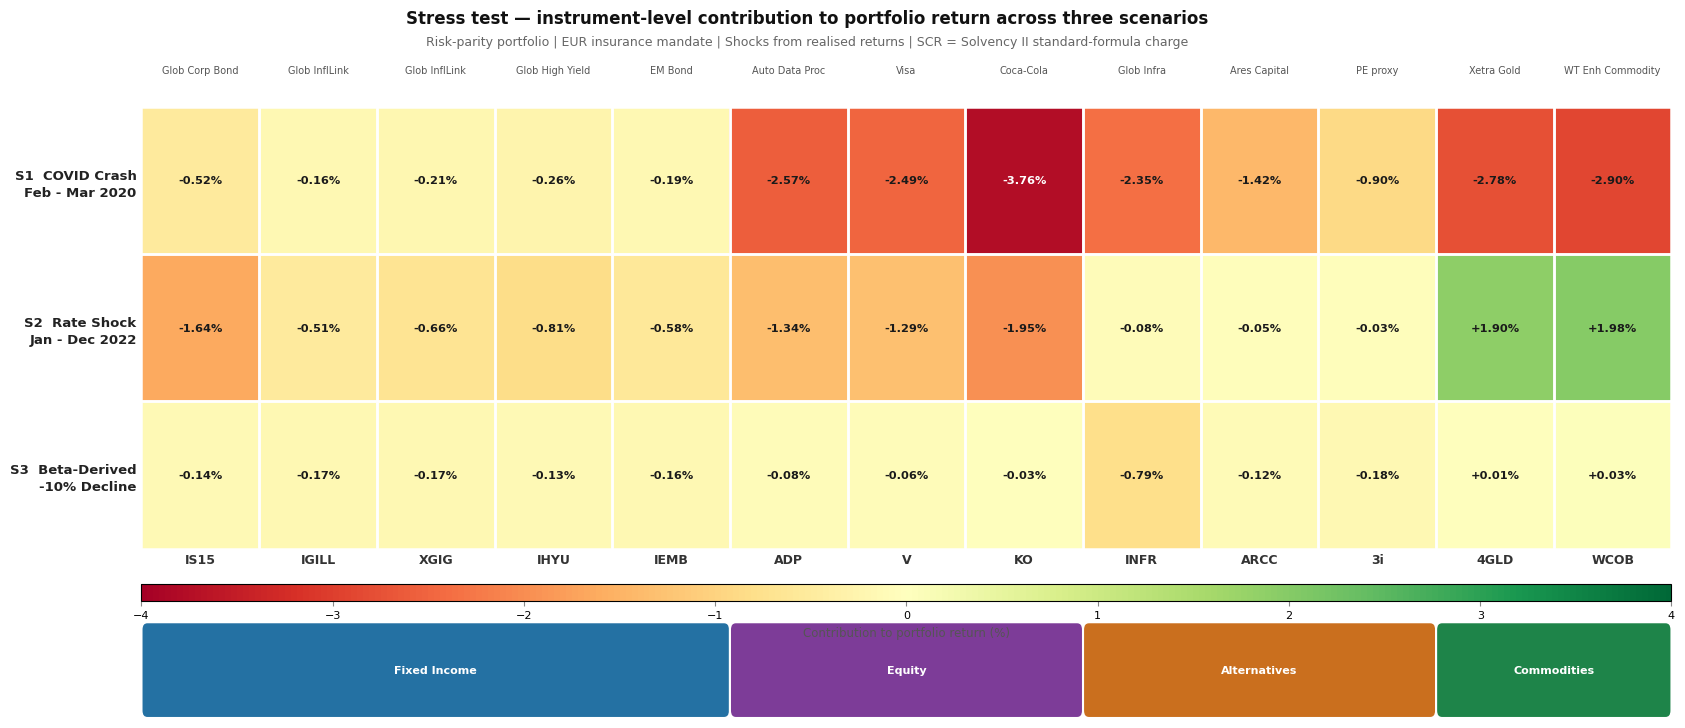

Chart 1 saved.


In [ ]:
# Chart 1: Heatmap: Instrument-Level Contributions

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.spines.bottom":False,
})

instruments    = list(WEIGHTS.keys())
short_labels   = ["IS15","IGILL","XGIG","IHYU","IEMB",
                  "ADP","V","KO","INFR","ARCC","3i","4GLD","WCOB"]
scenario_labels = [
    "S1  COVID Crash\nFeb - Mar 2020",
    "S2  Rate Shock\nJan - Dec 2022",
    "S3  Beta-Derived\n-10% Decline",
]

heat_data = np.array([
    [s1_df.set_index("Instrument").loc[i, "Contribution (%)"] for i in instruments],
    [s2_df.set_index("Instrument").loc[i, "Contribution (%)"] for i in instruments],
    [s3_df.set_index("Instrument").loc[i, "Contribution (%)"] for i in instruments],
])

totals  = [s1_port, s2_port, s3_port]
bm_tots = [s1_bm,   s2_bm,   s3_bm]
alphas  = [t - b for t, b in zip(totals, bm_tots)]

fig = plt.figure(figsize=(18, 6.5), facecolor="white")
ax  = fig.add_axes([0.13, 0.14, 0.85, 0.68])

vmax = 4.0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = plt.cm.RdYlGn
im   = ax.imshow(heat_data, cmap=cmap, norm=norm,
                 aspect="auto", interpolation="none")

for r in range(3):
    for c in range(13):
        ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1,
            fill=False, edgecolor="white", linewidth=1.8, zorder=4))

for r in range(3):
    for c in range(13):
        v   = heat_data[r, c]
        lum = 0.3*cmap(norm(v))[0] + 0.59*cmap(norm(v))[1] + 0.11*cmap(norm(v))[2]
        col = "white" if lum < 0.45 else "#1a1a1a"
        ax.text(c, r, f"{v:+.2f}%", ha="center", va="center",
                fontsize=8.2, fontweight="bold", color=col, zorder=5)

band_y, band_h = 3.05, 0.55
cls_runs = []
prev = None; start = 0
for i, inst in enumerate(instruments):
    c = ASSET_CLASSES[inst]
    if c != prev:
        if prev is not None: cls_runs.append((prev, start, i-1))
        prev = c; start = i
cls_runs.append((prev, start, len(instruments)-1))

for cls, s, e in cls_runs:
    mid = (s + e) / 2
    ax.add_patch(FancyBboxPatch((s-0.45, band_y), e-s+0.9, band_h,
        boxstyle="round,pad=0.05", facecolor=SLEEVE_COLORS[cls],
        edgecolor="white", linewidth=1.5, clip_on=False, zorder=6))
    ax.text(mid, band_y+band_h/2, cls, ha="center", va="center",
            fontsize=8, fontweight="bold", color="white", clip_on=False, zorder=7)

ax.set_xticks(range(13))
ax.set_xticklabels(short_labels, fontsize=9, fontweight="bold", color="#333")
for i, inst in enumerate(instruments):
    ax.text(i, -0.78, inst.split("(")[1].replace(")",""),
            ha="center", va="top", fontsize=7, color="#555", clip_on=False)

ax.set_yticks(range(3))
ax.set_yticklabels(scenario_labels, fontsize=9.5,
                   fontweight="bold", color="#222", linespacing=1.4)
ax.tick_params(length=0)

cbar_ax = fig.add_axes([0.13, 0.06, 0.85, 0.025])
cb = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cb.set_label("Contribution to portfolio return (%)", fontsize=8.5, color="#555")
cb.ax.tick_params(labelsize=8, color="#888")

fig.text(0.5, 0.97,
         "Stress test — instrument-level contribution to portfolio return across three scenarios",
         ha="center", va="top", fontsize=12, fontweight="bold", color="#111")
fig.text(0.5, 0.93,
         "Risk-parity portfolio | EUR insurance mandate | Shocks from realised returns | SCR = Solvency II standard-formula charge",
         ha="center", va="top", fontsize=9, color="#666")

plt.savefig("chart1_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Chart 1 saved.")

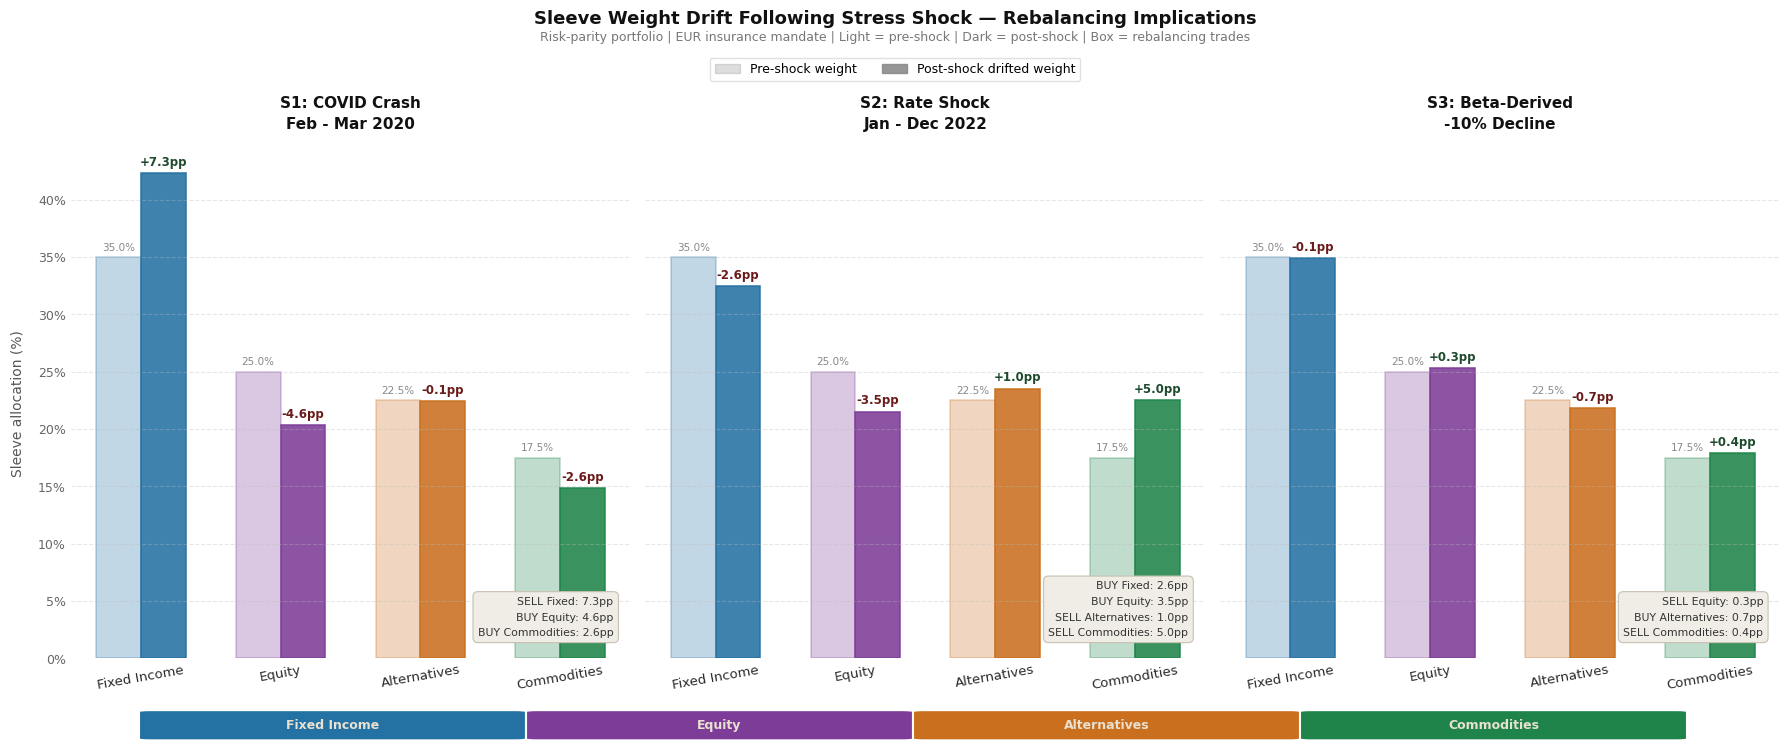

Chart 2 saved.


In [ ]:
# Chart 2: Sleeve Weight Drift & Rebalancing

sleeves     = ["Fixed Income", "Equity", "Alternatives", "Commodities"]
orig_sleeve = [sum(WEIGHTS[i] for i in WEIGHTS if ASSET_CLASSES[i]==s)*100 for s in sleeves]
drift_data = {
    "S1: COVID Crash\nFeb - Mar 2020":
        [sum(s1_drifted[i] for i in WEIGHTS if ASSET_CLASSES[i]==s)*100 for s in sleeves],
    "S2: Rate Shock\nJan - Dec 2022":
        [sum(s2_drifted[i] for i in WEIGHTS if ASSET_CLASSES[i]==s)*100 for s in sleeves],
    "S3: Beta-Derived\n-10% Decline":
        [sum(s3_drifted[i] for i in WEIGHTS if ASSET_CLASSES[i]==s)*100 for s in sleeves],
}
fig, axes = plt.subplots(1, 3, figsize=(18, 7), facecolor="white", sharey=True)
fig.subplots_adjust(wspace=0.06)
x = np.arange(len(sleeves)); width = 0.32
for col, (title, drift_vals) in enumerate(drift_data.items()):
    ax = axes[col]; ax.set_facecolor("white")
    for s_idx, (sleeve, orig, drift) in enumerate(zip(sleeves, orig_sleeve, drift_vals)):
        color = SLEEVE_COLORS[sleeve]; diff = drift - orig
        ax.bar(s_idx-width/2, orig,  width, color=color, alpha=0.28, edgecolor=color, linewidth=1.2)
        ax.bar(s_idx+width/2, drift, width, color=color, alpha=0.88, edgecolor=color, linewidth=1.2)
        ax.text(s_idx-width/2, orig+0.4,  f"{orig:.1f}%",
                ha="center", va="bottom", fontsize=7.5, color="#888")
        arrow_col = "#1e4a2e" if diff > 0 else "#6b1a1a"
        ax.text(s_idx+width/2, drift+0.4,
                f"{'+' if diff>0 else ''}{diff:.1f}pp",
                ha="center", va="bottom", fontsize=8.5,
                fontweight="bold", color=arrow_col)
    actions = [f"{'SELL' if drift-o>0 else 'BUY'} {s.split()[0]}: {abs(drift-o):.1f}pp"
               for s, o, drift in zip(sleeves, orig_sleeve, drift_vals) if abs(drift-o) > 0.3]
    if actions:
        ax.text(0.97, 0.04, "\n".join(actions), transform=ax.transAxes,
                ha="right", va="bottom", fontsize=7.8, color="#333", linespacing=1.7,
                bbox=dict(boxstyle="round,pad=0.45", facecolor="#f0ede6",
                          edgecolor="#c8c0b0", linewidth=0.8))
    ax.set_title(title, fontsize=11, fontweight="bold",
                 color="#111", linespacing=1.5, pad=14)
    ax.set_xticks(x)
    ax.set_xticklabels(sleeves, fontsize=9.5, color="#2a2a2a", rotation=10)
    ax.tick_params(length=0)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, color="#bbb", zorder=0)
    ax.tick_params(axis="y", labelsize=9, colors="#666")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0f}%"))
    if col == 0:
        ax.set_ylabel("Sleeve allocation (%)", fontsize=10, color="#555", labelpad=10)
band_ax = fig.add_axes([0.08, 0.01, 0.86, 0.045])
band_ax.set_xlim(0,4); band_ax.set_ylim(0,1); band_ax.axis("off")
band_ax.set_facecolor("white")
for i, sleeve in enumerate(sleeves):
    band_ax.add_patch(FancyBboxPatch((i+0.03,0.05), 0.94, 0.9,
        boxstyle="round,pad=0.03", facecolor=SLEEVE_COLORS[sleeve],
        edgecolor="white", linewidth=1.5))
    band_ax.text(i+0.5, 0.5, sleeve, ha="center", va="center",
                 fontsize=9, fontweight="bold", color="#e8e0d0")
fig.legend(handles=[
    Patch(facecolor="#888", alpha=0.28, edgecolor="#888", label="Pre-shock weight"),
    Patch(facecolor="#888", alpha=0.88, edgecolor="#888", label="Post-shock drifted weight"),
], loc="upper center", ncol=2, fontsize=9, framealpha=0.9,
   edgecolor="#ddd", facecolor="white", bbox_to_anchor=(0.5, 0.995))
fig.suptitle("Sleeve Weight Drift Following Stress Shock — Rebalancing Implications",
             fontsize=13, fontweight="bold", color="#111", y=1.055)
fig.text(0.5, 1.01,
         "Risk-parity portfolio | EUR insurance mandate | Light = pre-shock | Dark = post-shock | Box = rebalancing trades",
         ha="center", fontsize=9, color="#777")
fig.patch.set_facecolor("white")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("chart2_sleeve_drift.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Chart 2 saved.")